# TC 5035 - Proyecto Integrador
**Avance 3 - Baseline**

<br>

*   José Raúl Rodríguez Cantú     - A01795469
*   César Julián Camarillo Pérez  - A01795688
*   Joel Alejandro Romero Moya    -	A01168002

<br>

**Objetivos**

*   Establecer las medidas de calidad del modelo de aprendizaje automático.
*   Proporcionar un marco de referencia para evaluar y mejorar modelos más avanzados.


**Instrucciones**

Este avance consiste en construir un modelo de referencia que permita evaluar la viabilidad del problema. Si el baseline tiene un rendimiento similar al azar, podría indicar que el problema es intrínsecamente difícil o que los datos no contienen suficiente información para predecir el objetivo. De lo contrario, el baseline podría como una solución mínima aceptable cuando se trabaja en escenarios donde incluso un modelo simple puede proporcionar valor.

Un baseline facilita también la gestión de expectativas, tanto dentro del equipo como con los stakeholders, pues proporciona una comprensión inicial de lo que se puede lograr con métodos simples antes de invertir tiempo y recursos en enfoques más complejos.

Las siguientes son algunas de las preguntas que deberán abordar durante esta fase:



*   ¿Qué algoritmo se puede utilizar como baseline para predecir las variables objetivo?
*   ¿Se puede determinar la importancia de las características para el modelo generado? Recuerden que incluir características irrelevantes puede afectar negativamente el rendimiento del modelo y aumentar la complejidad sin beneficios sustanciales.
*   ¿El modelo está sub/sobreajustando los datos de entrenamiento?
*   ¿Cuál es la métrica adecuada para este problema de negocio?
*   ¿Cuál debería ser el desempeño mínimo a obtener?


**Criterios de evaluación**
- Algoritmo
- Características importantes
- Sub / sobreajuste
- Métrica
- Desempeño

## Resumen ejecutivo del enfoque

El flujo de trabajo del avance es el siguiente:

1. Cargar el dataset final pre-modelado.
2. Validar la variable objetivo.
3. Controlar posibles fugas de información.
4. Separar los datos en entrenamiento, validación y prueba.
5. Construir un modelo ingenuo de referencia.
6. Entrenar un modelo baseline interpretable.
7. Evaluar el desempeño mediante métricas alineadas al negocio.
8. Comparar el baseline contra un desempeño mínimo esperado.
9. Analizar subajuste, sobreajuste y estabilidad.
10. Identificar características importantes.
11. Analizar errores por segmento de ingreso.
12. Concluir si el baseline es una referencia útil para modelos futuros.

In [ ]:
# ============================================================
# 1. Importación de librerías y configuración general
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    KFold,
    cross_validate
)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.inspection import permutation_importance
from sklearn.base import clone

# Configuración visual
pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

# Semilla para reproducibilidad
RANDOM_STATE = 42

# Variable objetivo
TARGET = "AVG_ING_MENSUAL"

print("Configuración inicial completada.")
print("Variable objetivo:", TARGET)

Configuración inicial completada.
Variable objetivo: AVG_ING_MENSUAL


## 1. Carga del dataset final pre-modelado

Para este avance se utiliza como punto de partida el archivo `df_final_pre_modelado.csv`, generado al final del proceso previo de integración, limpieza e ingeniería de características.

Este dataset ya contiene variables consolidadas de nómina, perfil sociodemográfico, información geográfica, movilidad y buró de crédito. Por lo tanto, este notebook se enfoca exclusivamente en construir, evaluar e interpretar el modelo baseline.

In [ ]:
# ============================================================
# 2. Carga del dataset final pre-modelado
# ============================================================
DATA_PATH = "df_final_pre_modelado_2.csv"

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("Shape del dataset:", df.shape)
print("Columnas disponibles:", df.shape[1])

display(df.head())

Shape del dataset: (28735, 76)
Columnas disponibles: 76


,NUM_EMPRESAS,MEDIANA_DAYS_FREQ,AVG_DAYS_FREQ,AVG_ING_MENSUAL,SEXO,ESTADO_CIVIL,CIUDAD,CODIGO_ESTADO,CP,latitude,longitude,score,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode,COUNT_6M,COUNT_9M,COUNT_12M,COUNT_18M,COUNT_24M,COUNT_MAS_24M,COUNT_AUTOCONS,NUM_DIF_TRAM,NUM_DIF_CONS,FLAG_CAMBIO_3M,FLAG_CAMBIO_6M,FLAG_CAMBIO_9M,FLAG_CAMBIO_12M,FLAG_CAMBIO_18M,FLAG_CAMBIO_24M,COUNT_FLAG_CLOSED,COUNT_FLAG_OPEN,COUNT_FLAG_OTORG_AFIRME,COUNT_FLAG_SALDO_VDO,COUNT_FLAG_REEST,COUNT_FLAG_6M,COUNT_FLAG_12M,COUNT_FLAG_18M,COUNT_FLAG_24M,COUNT_FLAG_MAS_24M,MAX_PEOR_MOP_IN_3M,MAX_PEOR_MOP_IN_6M,MAX_PEOR_MOP_IN_9M,MAX_PEOR_MOP_IN_12M,MAX_PEOR_MOP_IN_18M,MAX_PEOR_MOP_IN_24M,SUM_TL_SALDO_ACTUAL,SUM_TL_SALDO_VENCIDO,SUM_MONTO_OTORG,AVG_MESES_ENTRE_CUENTAS_APER,MAX_MESES_ENTRE_CUENTAS_APER,MIN_MESES_ENTRE_CUENTAS_APER,COUNT_DIST_OTORG,COUNT_DIST_CTO,EDAD,ANTIGUEDAD_CLIENTE_ANIOS,ANTIGUEDAD_NOMINA_MESES,FLAG_GEO_MISSING,FLAG_SCORE_BAJO,FLAG_DISTANCIA_EXTREMA,FLAG_TIEMPO_EXTREMO,FLAG_TIENE_SALDO_VENCIDO,FLAG_TIENE_MONTO_OTORGADO,RATIO_SALDO_ACTUAL_MONTO,RATIO_SALDO_VENCIDO_ACTUAL,MOP_MAX_24M,FLAG_MOP_MALO,RATIO_CONSULTAS_6M_24M,FLAG_ALTA_BUSQUEDA_CREDITO,FLAG_RATIO_SALDO_ACTUAL_ALTO,FLAG_RATIO_VENCIDO_ALTO
0,1,15.00,14.47,"11,643.90",F,1,CHILPANCINGO DE LOS BRAVO,GRO,39100,NaN,NaN,NaN,2.80,3.15,3.50,8,8.50,14,12.00,light,1,1,1,2,2,0,0.00,2.00,1.00,1,1,1,1,1,1,4.00,158.00,126.00,1.00,0.00,6,13,18,23,139,9.00,9.00,9.00,9.00,9.00,9.00,"44,275.00","11,747.00","1,398,920.00",65.73,206.00,1.00,4,5,70.60,10.22,127.77,1,0,0,0,1,1,0.03,0.27,9.00,1,0.33,0,0,0
1,1,15.00,15.41,"85,064.55",M,2,GENERAL ESCOBEDO,NL,66055,25.78,-100.32,96.09,1.80,2.27,2.60,5,6.00,12,10.00,light,7,7,7,7,7,0,0.00,2.00,2.00,0,1,1,1,1,1,3.00,43.00,42.00,0.00,0.00,1,1,1,1,45,1.00,1.00,1.00,1.00,1.00,1.00,"218,159.00",0.00,"1,429,049.00",155.48,286.00,0.00,4,6,48.17,26.70,136.43,0,0,0,0,0,1,0.15,0.00,1.00,0,0.88,0,0,0
2,1,15.00,15.35,"28,767.61",M,1,MONTERREY,NL,64280,25.71,-100.34,100.00,3.80,4.33,4.60,9,9.67,28,24.67,hard,1,2,7,8,8,0,2.00,3.00,5.00,0,0,0,0,0,1,6.00,55.00,54.00,1.00,0.00,0,0,1,1,60,2.00,2.00,2.00,2.00,2.00,2.00,"56,075.00","10,510.00","867,732.00",129.69,236.00,15.00,5,4,46.26,20.02,136.43,0,0,0,0,1,1,0.06,0.19,2.00,0,0.11,0,0,0
3,2,7.00,6.96,"11,320.89",M,1,OTRAS,NL,66055,25.78,-100.32,98.17,1.20,1.25,1.30,4,4.00,6,5.00,light,14,17,17,18,20,0,0.00,5.00,8.00,0,0,1,1,1,1,6.00,61.00,0.00,0.00,0.00,8,19,25,29,38,1.00,1.00,1.00,1.00,1.00,1.00,"30,772.00",0.00,"228,760.00",42.78,430.00,0.00,7,5,57.97,8.15,101.93,0,0,0,0,0,1,0.13,0.00,1.00,0,0.67,1,0,0
4,1,7.00,7.32,"16,825.60",M,2,OTRAS,NL,67515,25.21,-99.86,84.00,6.60,6.80,7.00,14,15.00,16,15.00,NaN,3,3,4,4,4,0,0.00,3.00,2.00,0,0,0,0,0,0,9.00,44.00,3.00,1.00,0.00,1,6,7,11,42,3.00,3.00,3.00,3.00,3.00,3.00,"304,652.00","1,463.00","738,346.00",67.21,130.00,4.00,5,4,55.58,7.64,99.87,0,1,0,0,1,1,0.41,0.00,3.00,0,0.60,0,0,0


In [ ]:
# ============================================================
# 3. Revisión inicial de estructura
# ============================================================

print("Información general del dataset:")
display(df.info())

print("\nPrimeras columnas:")
print(df.columns.tolist()[:30])

print("\nÚltimas columnas:")
print(df.columns.tolist()[-30:])

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28735 entries, 0 to 28734
Data columns (total 76 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   NUM_EMPRESAS                  28735 non-null  int64  
 1   MEDIANA_DAYS_FREQ             28709 non-null  float64
 2   AVG_DAYS_FREQ                 28709 non-null  float64
 3   AVG_ING_MENSUAL               28735 non-null  float64
 4   SEXO                          28735 non-null  object 
 5   ESTADO_CIVIL                  28735 non-null  int64  
 6   CIUDAD                        28735 non-null  object 
 7   CODIGO_ESTADO                 28735 non-null  object 
 8   CP                            28735 non-null  int64  
 9   latitude                      25422 non-null  float64
 10  longitude                     25422 non-null  float64
 11  score                         25422 non-null  float64
 12  dist_min_km                

None


Primeras columnas:
['NUM_EMPRESAS', 'MEDIANA_DAYS_FREQ', 'AVG_DAYS_FREQ', 'AVG_ING_MENSUAL', 'SEXO', 'ESTADO_CIVIL', 'CIUDAD', 'CODIGO_ESTADO', 'CP', 'latitude', 'longitude', 'score', 'dist_min_km', 'dist_mean_km', 'dist_max_km', 'time_min_min', 'time_min_mean', 'time_max_max', 'time_max_mean', 'traffic_mode', 'COUNT_6M', 'COUNT_9M', 'COUNT_12M', 'COUNT_18M', 'COUNT_24M', 'COUNT_MAS_24M', 'COUNT_AUTOCONS', 'NUM_DIF_TRAM', 'NUM_DIF_CONS', 'FLAG_CAMBIO_3M']

Últimas columnas:
['MAX_PEOR_MOP_IN_6M', 'MAX_PEOR_MOP_IN_9M', 'MAX_PEOR_MOP_IN_12M', 'MAX_PEOR_MOP_IN_18M', 'MAX_PEOR_MOP_IN_24M', 'SUM_TL_SALDO_ACTUAL', 'SUM_TL_SALDO_VENCIDO', 'SUM_MONTO_OTORG', 'AVG_MESES_ENTRE_CUENTAS_APER', 'MAX_MESES_ENTRE_CUENTAS_APER', 'MIN_MESES_ENTRE_CUENTAS_APER', 'COUNT_DIST_OTORG', 'COUNT_DIST_CTO', 'EDAD', 'ANTIGUEDAD_CLIENTE_ANIOS', 'ANTIGUEDAD_NOMINA_MESES', 'FLAG_GEO_MISSING', 'FLAG_SCORE_BAJO', 'FLAG_DISTANCIA_EXTREMA', 'FLAG_TIEMPO_EXTREMO', 'FLAG_TIENE_SALDO_VENCIDO', 'FLAG_TIENE_MONTO_OTORGADO'

## 2. Validación de la variable objetivo

La variable objetivo seleccionada es `AVG_ING_MENSUAL`, que representa el ingreso mensual promedio observado del cliente.

Esta variable es relevante para el negocio porque puede funcionar como una aproximación a la capacidad económica del cliente y como insumo para validar la consistencia de ingresos declarados. Sin embargo, es importante aclarar que este modelo no predice directamente incumplimiento, mora o probabilidad de default.

Debido a que las variables de ingreso suelen presentar distribuciones asimétricas y valores extremos, se evaluará la distribución original y su transformación logarítmica.

In [ ]:
# ============================================================
# 4. Validación de la variable objetivo
# ============================================================

if TARGET not in df.columns:
    raise ValueError(f"La variable objetivo {TARGET} no existe en el dataset.")

# Convertir target a numérico de forma robusta
df[TARGET] = (
    df[TARGET]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

print("Variable objetivo:", TARGET)
print("Tipo de dato:", df[TARGET].dtype)
print("Nulos en target:", df[TARGET].isna().sum())
print("Valores <= 0:", (df[TARGET] <= 0).sum())

display(
    df[TARGET].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Variable objetivo: AVG_ING_MENSUAL
Tipo de dato: float64
Nulos en target: 0
Valores <= 0: 0


,AVG_ING_MENSUAL
count,"28,735.00"
mean,"16,697.26"
std,"21,170.30"
min,745.35
1%,"3,375.56"
5%,"5,855.45"
25%,"8,946.64"
50%,"12,334.40"
75%,"18,844.78"
90%,"29,060.49"


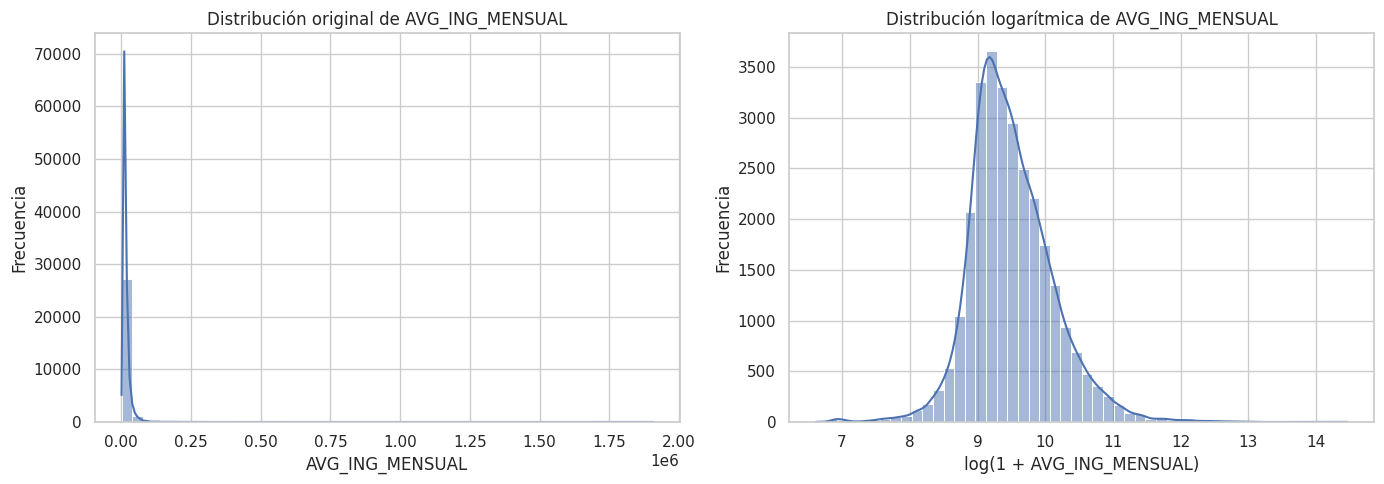

In [ ]:
# ============================================================
# 5. Visualización de la variable objetivo
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[TARGET].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribución original de AVG_ING_MENSUAL")
axes[0].set_xlabel("AVG_ING_MENSUAL")
axes[0].set_ylabel("Frecuencia")

sns.histplot(np.log1p(df[TARGET].dropna()), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribución logarítmica de AVG_ING_MENSUAL")
axes[1].set_xlabel("log(1 + AVG_ING_MENSUAL)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

La distribución de `AVG_ING_MENSUAL` presenta asimetría hacia la derecha, lo cual es común en variables de ingreso. Esto significa que una proporción pequeña de clientes puede tener ingresos considerablemente superiores al resto.

Por esta razón, aunque las métricas finales se reportarán en la escala original de pesos mexicanos, el modelo Ridge baseline se entrenará con una transformación logarítmica del target. Esta decisión busca reducir la influencia desproporcionada de valores extremos durante el entrenamiento.

In [ ]:
# ============================================================
# 6. Limpieza mínima del target
# ============================================================

print("Registros originales:", df.shape[0])

df_model = df.copy()

# Reemplazar infinitos por nulos
df_model = df_model.replace([np.inf, -np.inf], np.nan)

# Eliminar registros sin target o con target no positivo
df_model = df_model.dropna(subset=[TARGET]).copy()
df_model = df_model[df_model[TARGET] > 0].copy()

print("Registros después de limpiar target:", df_model.shape[0])
print("Registros eliminados:", df.shape[0] - df_model.shape[0])

display(
    df_model[TARGET].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Registros originales: 28735
Registros después de limpiar target: 28735
Registros eliminados: 0


,AVG_ING_MENSUAL
count,"28,735.00"
mean,"16,697.26"
std,"21,170.30"
min,745.35
1%,"3,375.56"
5%,"5,855.45"
25%,"8,946.64"
50%,"12,334.40"
75%,"18,844.78"
90%,"29,060.49"


## 3. Control de fuga de información

Antes de entrenar el modelo se validó la presencia de variables que podrían generar fuga de información o inducir al modelo a memorizar registros.

La variable objetivo `AVG_ING_MENSUAL` se excluye de las variables predictoras. Además, se contempla la exclusión de variables altamente relacionadas con el target, como `MEDIANA_ING_MENSUAL`, en caso de estar presentes en el dataset.

También se excluyen identificadores como `NUMERO_CLIENTE` e `ID_BURO_FINAL`, ya que no representan características generalizables del cliente y podrían inducir al modelo a memorizar registros en lugar de aprender patrones replicables.

In [ ]:
# ============================================================
# 7. Tratamiento conceptual de variables categóricas
# ============================================================

df_model = df_model.copy()

# Variables que conceptualmente son categóricas aunque puedan venir como número
categorical_semantic_cols = [
    "SEXO",
    "ESTADO_CIVIL",
    "CIUDAD",
    "CODIGO_ESTADO",
    "traffic_mode"
]

# El código postal completo puede tener alta cardinalidad.
# Se genera un prefijo para capturar zona geográfica de forma más estable.
possible_high_cardinality_cols = [
    "CALLE",
    "COLONIA",
    "direccion_sugerida",
    "CP_CALCULADO"
]

if "CP" in df_model.columns:
    df_model["CP_PREFIX"] = (
        df_model["CP"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.zfill(5)
        .str[:2]
    )

    possible_high_cardinality_cols.append("CP")
    categorical_semantic_cols.append("CP_PREFIX")

# Convertir variables conceptualmente categóricas
for col in categorical_semantic_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype("category")

print("Variables categóricas semánticas tratadas:")
print([col for col in categorical_semantic_cols if col in df_model.columns])

Variables categóricas semánticas tratadas:
['SEXO', 'ESTADO_CIVIL', 'CIUDAD', 'CODIGO_ESTADO', 'traffic_mode', 'CP_PREFIX']


Adicionalmente, se revisó el tipo conceptual de algunas variables. Variables como código postal, estado civil, ciudad y estado geográfico no representan cantidades continuas, aunque algunas puedan estar codificadas numéricamente.

Por ello, se trataron como variables categóricas.En el caso de `CP`, se generó `CP_PREFIX` como una posible variable geográfica agregada. Sin embargo, durante el preprocesamiento se evalúa su cardinalidad y, si supera el umbral definido, se excluye para evitar una expansión excesiva de variables mediante one-hot encoding.

In [ ]:
# ============================================================
# 8. Definición de columnas excluidas del modelado
# ============================================================

# Identificadores
id_cols = [
    "NUMERO_CLIENTE",
    "ID_BURO_FINAL"
]

# Variables con posible fuga de información
leakage_cols = [
    "MEDIANA_ING_MENSUAL"
]

# Fechas crudas, en caso de permanecer en el dataset
raw_date_cols = [
    "FECHA_NACIMIENTO",
    "FECHA_CLIENTE_DESDE",
    "FECHA_FIRST_DEPOSITO",
    "MONTH_LAST_DEPOSITO",
    "FECHA_RANGO_IZQ",
    "FECHA_LAST_DEPOSITO_x",
    "FECHA_LAST_DEPOSITO_y",
    "FECHA_CONS_FINAL"
]

# Consolidar columnas a excluir
cols_to_drop = (
    [TARGET] +
    id_cols +
    leakage_cols +
    possible_high_cardinality_cols +
    raw_date_cols
)

# Quitar duplicados conservando orden
cols_to_drop = list(dict.fromkeys(cols_to_drop))

# Conservar solo columnas existentes
cols_to_drop = [col for col in cols_to_drop if col in df_model.columns]

print("Columnas excluidas del modelado:")
for col in cols_to_drop:
    print("-", col)

Columnas excluidas del modelado:
- AVG_ING_MENSUAL
- CP


In [ ]:
# ============================================================
# 9. Auditoría de variables excluidas
# ============================================================

columnas_a_revisar = (
    [TARGET] +
    id_cols +
    leakage_cols +
    possible_high_cardinality_cols +
    raw_date_cols
)

columnas_a_revisar = list(dict.fromkeys(columnas_a_revisar))

auditoria_exclusion = pd.DataFrame({
    "columna": columnas_a_revisar,
    "existe_en_dataset": [col in df_model.columns for col in columnas_a_revisar],
    "se_excluye": [col in cols_to_drop for col in columnas_a_revisar]
})

display(auditoria_exclusion)

,columna,existe_en_dataset,se_excluye
0,AVG_ING_MENSUAL,True,True
1,NUMERO_CLIENTE,False,False
2,ID_BURO_FINAL,False,False
3,MEDIANA_ING_MENSUAL,False,False
4,CALLE,False,False
5,COLONIA,False,False
6,direccion_sugerida,False,False
7,CP_CALCULADO,False,False
8,CP,True,True
9,FECHA_NACIMIENTO,False,False


## 4. Separación de variables predictoras y variable objetivo

Después de excluir la variable objetivo, identificadores, variables con posible fuga de información y variables crudas de alta cardinalidad, se separa el dataset en:

- `X`: variables predictoras.
- `y`: variable objetivo `AVG_ING_MENSUAL`.

Esta separación permite construir un flujo de modelado supervisado donde el algoritmo aprende patrones a partir de las características disponibles para estimar el ingreso mensual promedio.

In [ ]:
# ============================================================
# 10. Separación de X e y
# ============================================================

y = df_model[TARGET].astype(float)

X = df_model.drop(
    columns=cols_to_drop,
    errors="ignore"
).copy()

print("Shape X:", X.shape)
print("Shape y:", y.shape)

display(X.head())

Shape X: (28735, 75)
Shape y: (28735,)


,NUM_EMPRESAS,MEDIANA_DAYS_FREQ,AVG_DAYS_FREQ,SEXO,ESTADO_CIVIL,CIUDAD,CODIGO_ESTADO,latitude,longitude,score,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode,COUNT_6M,COUNT_9M,COUNT_12M,COUNT_18M,COUNT_24M,COUNT_MAS_24M,COUNT_AUTOCONS,NUM_DIF_TRAM,NUM_DIF_CONS,FLAG_CAMBIO_3M,FLAG_CAMBIO_6M,FLAG_CAMBIO_9M,FLAG_CAMBIO_12M,FLAG_CAMBIO_18M,FLAG_CAMBIO_24M,COUNT_FLAG_CLOSED,COUNT_FLAG_OPEN,COUNT_FLAG_OTORG_AFIRME,COUNT_FLAG_SALDO_VDO,COUNT_FLAG_REEST,COUNT_FLAG_6M,COUNT_FLAG_12M,COUNT_FLAG_18M,COUNT_FLAG_24M,COUNT_FLAG_MAS_24M,MAX_PEOR_MOP_IN_3M,MAX_PEOR_MOP_IN_6M,MAX_PEOR_MOP_IN_9M,MAX_PEOR_MOP_IN_12M,MAX_PEOR_MOP_IN_18M,MAX_PEOR_MOP_IN_24M,SUM_TL_SALDO_ACTUAL,SUM_TL_SALDO_VENCIDO,SUM_MONTO_OTORG,AVG_MESES_ENTRE_CUENTAS_APER,MAX_MESES_ENTRE_CUENTAS_APER,MIN_MESES_ENTRE_CUENTAS_APER,COUNT_DIST_OTORG,COUNT_DIST_CTO,EDAD,ANTIGUEDAD_CLIENTE_ANIOS,ANTIGUEDAD_NOMINA_MESES,FLAG_GEO_MISSING,FLAG_SCORE_BAJO,FLAG_DISTANCIA_EXTREMA,FLAG_TIEMPO_EXTREMO,FLAG_TIENE_SALDO_VENCIDO,FLAG_TIENE_MONTO_OTORGADO,RATIO_SALDO_ACTUAL_MONTO,RATIO_SALDO_VENCIDO_ACTUAL,MOP_MAX_24M,FLAG_MOP_MALO,RATIO_CONSULTAS_6M_24M,FLAG_ALTA_BUSQUEDA_CREDITO,FLAG_RATIO_SALDO_ACTUAL_ALTO,FLAG_RATIO_VENCIDO_ALTO,CP_PREFIX
0,1,15.00,14.47,F,1,CHILPANCINGO DE LOS BRAVO,GRO,NaN,NaN,NaN,2.80,3.15,3.50,8,8.50,14,12.00,light,1,1,1,2,2,0,0.00,2.00,1.00,1,1,1,1,1,1,4.00,158.00,126.00,1.00,0.00,6,13,18,23,139,9.00,9.00,9.00,9.00,9.00,9.00,"44,275.00","11,747.00","1,398,920.00",65.73,206.00,1.00,4,5,70.60,10.22,127.77,1,0,0,0,1,1,0.03,0.27,9.00,1,0.33,0,0,0,39
1,1,15.00,15.41,M,2,GENERAL ESCOBEDO,NL,25.78,-100.32,96.09,1.80,2.27,2.60,5,6.00,12,10.00,light,7,7,7,7,7,0,0.00,2.00,2.00,0,1,1,1,1,1,3.00,43.00,42.00,0.00,0.00,1,1,1,1,45,1.00,1.00,1.00,1.00,1.00,1.00,"218,159.00",0.00,"1,429,049.00",155.48,286.00,0.00,4,6,48.17,26.70,136.43,0,0,0,0,0,1,0.15,0.00,1.00,0,0.88,0,0,0,66
2,1,15.00,15.35,M,1,MONTERREY,NL,25.71,-100.34,100.00,3.80,4.33,4.60,9,9.67,28,24.67,hard,1,2,7,8,8,0,2.00,3.00,5.00,0,0,0,0,0,1,6.00,55.00,54.00,1.00,0.00,0,0,1,1,60,2.00,2.00,2.00,2.00,2.00,2.00,"56,075.00","10,510.00","867,732.00",129.69,236.00,15.00,5,4,46.26,20.02,136.43,0,0,0,0,1,1,0.06,0.19,2.00,0,0.11,0,0,0,64
3,2,7.00,6.96,M,1,OTRAS,NL,25.78,-100.32,98.17,1.20,1.25,1.30,4,4.00,6,5.00,light,14,17,17,18,20,0,0.00,5.00,8.00,0,0,1,1,1,1,6.00,61.00,0.00,0.00,0.00,8,19,25,29,38,1.00,1.00,1.00,1.00,1.00,1.00,"30,772.00",0.00,"228,760.00",42.78,430.00,0.00,7,5,57.97,8.15,101.93,0,0,0,0,0,1,0.13,0.00,1.00,0,0.67,1,0,0,66
4,1,7.00,7.32,M,2,OTRAS,NL,25.21,-99.86,84.00,6.60,6.80,7.00,14,15.00,16,15.00,NaN,3,3,4,4,4,0,0.00,3.00,2.00,0,0,0,0,0,0,9.00,44.00,3.00,1.00,0.00,1,6,7,11,42,3.00,3.00,3.00,3.00,3.00,3.00,"304,652.00","1,463.00","738,346.00",67.21,130.00,4.00,5,4,55.58,7.64,99.87,0,1,0,0,1,1,0.41,0.00,3.00,0,0.60,0,0,0,67


In [ ]:
# ============================================================
# 11. Validación de tipos de variables predictoras
# ============================================================

numeric_cols_preview = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols_preview = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Número de variables numéricas:", len(numeric_cols_preview))
print("Número de variables categóricas:", len(categorical_cols_preview))

print("\nVariables categóricas:")
print(categorical_cols_preview)

print("\nEjemplo de variables numéricas:")
print(numeric_cols_preview[:30])

Número de variables numéricas: 69
Número de variables categóricas: 6

Variables categóricas:
['SEXO', 'ESTADO_CIVIL', 'CIUDAD', 'CODIGO_ESTADO', 'traffic_mode', 'CP_PREFIX']

Ejemplo de variables numéricas:
['NUM_EMPRESAS', 'MEDIANA_DAYS_FREQ', 'AVG_DAYS_FREQ', 'latitude', 'longitude', 'score', 'dist_min_km', 'dist_mean_km', 'dist_max_km', 'time_min_min', 'time_min_mean', 'time_max_max', 'time_max_mean', 'COUNT_6M', 'COUNT_9M', 'COUNT_12M', 'COUNT_18M', 'COUNT_24M', 'COUNT_MAS_24M', 'COUNT_AUTOCONS', 'NUM_DIF_TRAM', 'NUM_DIF_CONS', 'FLAG_CAMBIO_3M', 'FLAG_CAMBIO_6M', 'FLAG_CAMBIO_9M', 'FLAG_CAMBIO_12M', 'FLAG_CAMBIO_18M', 'FLAG_CAMBIO_24M', 'COUNT_FLAG_CLOSED', 'COUNT_FLAG_OPEN']


## 5. División de entrenamiento, validación y prueba

El dataset se divide en tres conjuntos:

- Entrenamiento: utilizado para ajustar el modelo.
- Validación: utilizado para seleccionar decisiones simples del baseline y analizar estabilidad.
- Prueba: utilizado como evaluación final sobre datos no vistos.

Debido a que `AVG_ING_MENSUAL` presenta una distribución asimétrica, la partición se realiza estratificando por deciles de ingreso. Esto permite que los conjuntos de entrenamiento, validación y prueba mantengan distribuciones similares del target.

In [ ]:
# ============================================================
# 12. Train / Validation / Test split estratificado por deciles
# ============================================================

# Crear bins por deciles del target para estratificación
# Si existen pocos valores únicos, se omite la estratificación.
try:
    y_bins = pd.qcut(y, q=10, duplicates="drop")
    usar_estratificacion = y_bins.nunique() > 1
except Exception:
    y_bins = None
    usar_estratificacion = False

if usar_estratificacion:
    X_train, X_temp, y_train, y_temp, bins_train, bins_temp = train_test_split(
        X,
        y,
        y_bins,
        train_size=0.60,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=y_bins
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=bins_temp
    )
else:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        train_size=0.60,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=RANDOM_STATE,
        shuffle=True
    )

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

comparacion_target = pd.DataFrame({
    "train": y_train.describe(),
    "validation": y_val.describe(),
    "test": y_test.describe()
})

display(comparacion_target)

Train: (17241, 75)
Validation: (5747, 75)
Test: (5747, 75)


,train,validation,test
count,"17,241.00","5,747.00","5,747.00"
mean,"16,698.18","16,810.56","16,581.18"
std,"22,794.01","20,814.09","15,782.45"
min,820.50,"1,000.00",745.35
25%,"8,950.40","8,974.32","8,923.38"
50%,"12,335.93","12,334.07","12,334.94"
75%,"18,873.87","18,755.43","18,864.14"
max,"1,906,696.15","859,956.42","240,469.97"


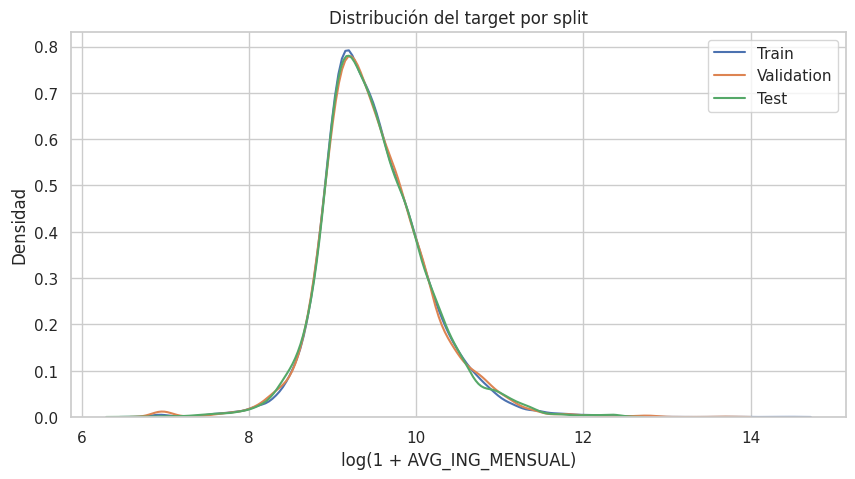

In [ ]:
# ============================================================
# 13. Comparación visual de distribución del target por split
# ============================================================

plt.figure(figsize=(10, 5))

sns.kdeplot(np.log1p(y_train), label="Train", fill=False)
sns.kdeplot(np.log1p(y_val), label="Validation", fill=False)
sns.kdeplot(np.log1p(y_test), label="Test", fill=False)

plt.title("Distribución del target por split")
plt.xlabel("log(1 + AVG_ING_MENSUAL)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.show()

## 6. Métricas de evaluación

La métrica principal seleccionada es MAE, ya que permite interpretar el error promedio del modelo directamente en pesos mexicanos. Esto facilita traducir el desempeño técnico a una lectura de negocio: cuánto se equivoca el modelo, en promedio, al estimar el ingreso mensual del cliente.

También se reportan métricas complementarias:

- RMSE: penaliza con mayor fuerza errores grandes.
- MedAE: mide el error mediano y es robusto ante outliers.
- MAPE: expresa el error en términos relativos, aunque puede ser sensible a valores pequeños.
- WAPE: mide el error absoluto total en proporción al volumen total observado.
- R²: indica qué proporción de la variabilidad del target logra explicar el modelo.

In [ ]:
# ============================================================
# 14. Función de evaluación
# ============================================================

def evaluar_regresion(nombre_modelo, y_true, y_pred):
    """
    Calcula métricas principales para evaluar modelos de regresión.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    medae = median_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # WAPE: error absoluto ponderado por volumen observado
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

    return {
        "modelo": nombre_modelo,
        "MAE": mae,
        "RMSE": rmse,
        "MedAE": medae,
        "MAPE": mape,
        "WAPE": wape,
        "R2": r2
    }


def formatear_metricas(df_metricas):
    """
    Da formato ejecutivo a una tabla de métricas.
    """
    df_fmt = df_metricas.copy()

    for col in ["MAE", "RMSE", "MedAE"]:
        if col in df_fmt.columns:
            df_fmt[col] = df_fmt[col].map("${:,.2f}".format)

    for col in ["MAPE", "WAPE"]:
        if col in df_fmt.columns:
            df_fmt[col] = df_fmt[col].map("{:.2%}".format)

    if "R2" in df_fmt.columns:
        df_fmt["R2"] = df_fmt["R2"].map("{:.4f}".format)

    return df_fmt

## 7. Modelo ingenuo de referencia

Como primer punto de comparación se construye un modelo ingenuo utilizando `DummyRegressor`. Este modelo predice siempre la mediana del ingreso mensual observada en el conjunto de entrenamiento.

Se eligió la mediana porque `AVG_ING_MENSUAL` presenta valores extremos, y la mediana es más robusta que el promedio ante distribuciones asimétricas.

Este modelo no utiliza información de las variables predictoras, por lo que funciona como una referencia mínima. Cualquier modelo baseline útil debería mejorar su desempeño frente a esta predicción trivial.

In [ ]:
# ============================================================
# 15. Modelo ingenuo: Dummy Regressor
# ============================================================

dummy = DummyRegressor(strategy="median")

dummy.fit(X_train, y_train)

dummy_pred_train = dummy.predict(X_train)
dummy_pred_val = dummy.predict(X_val)
dummy_pred_test = dummy.predict(X_test)

resultados_dummy = pd.DataFrame([
    evaluar_regresion("Dummy Median - Train", y_train, dummy_pred_train),
    evaluar_regresion("Dummy Median - Validation", y_val, dummy_pred_val),
    evaluar_regresion("Dummy Median - Test", y_test, dummy_pred_test)
])

display(resultados_dummy)
display(formatear_metricas(resultados_dummy))

,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Dummy Median - Train,"7,923.93","23,207.02","4,158.59",0.46,0.47,-0.04
1,Dummy Median - Validation,"8,073.43","21,287.87","4,161.96",0.48,0.48,-0.05
2,Dummy Median - Test,"7,827.20","16,342.11","4,137.53",0.46,0.47,-0.07


,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Dummy Median - Train,"$7,923.93","$23,207.02","$4,158.59",46.25%,47.45%,-0.0366
1,Dummy Median - Validation,"$8,073.43","$21,287.87","$4,161.96",48.48%,48.03%,-0.0462
2,Dummy Median - Test,"$7,827.20","$16,342.11","$4,137.53",46.26%,47.21%,-0.0724


## 8. Preprocesamiento para el modelo baseline

El modelo baseline requiere transformar las variables antes del entrenamiento. Para ello se construye un pipeline de preprocesamiento con tratamientos diferenciados:

- Variables numéricas: imputación con mediana y estandarización.
- Variables categóricas: imputación con moda y codificación one-hot.
- Variables categóricas de alta cardinalidad: exclusión para evitar expansión excesiva de variables y ruido en el modelo.

El preprocesamiento se ajusta únicamente con el conjunto de entrenamiento para evitar fuga de información hacia validación o prueba.

In [ ]:
# ============================================================
# 16. Identificación de variables numéricas y categóricas
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

MAX_CARDINALITY = 50

low_cardinality_cats = [
    col for col in categorical_features
    if X_train[col].nunique(dropna=True) <= MAX_CARDINALITY
]

high_cardinality_cats = [
    col for col in categorical_features
    if X_train[col].nunique(dropna=True) > MAX_CARDINALITY
]

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas de baja cardinalidad:", len(low_cardinality_cats))
print("Variables categóricas excluidas por alta cardinalidad:", high_cardinality_cats)

# Excluir categóricas de alta cardinalidad
X_train_model = X_train.drop(columns=high_cardinality_cats, errors="ignore")
X_val_model = X_val.drop(columns=high_cardinality_cats, errors="ignore")
X_test_model = X_test.drop(columns=high_cardinality_cats, errors="ignore")

# Actualizar listas después de exclusiones
numeric_features = [
    col for col in numeric_features
    if col in X_train_model.columns
]

categorical_features = [
    col for col in low_cardinality_cats
    if col in X_train_model.columns
]

print("\nVariables finales numéricas:", len(numeric_features))
print("Variables finales categóricas:", len(categorical_features))

Variables numéricas: 69
Variables categóricas de baja cardinalidad: 5
Variables categóricas excluidas por alta cardinalidad: ['CP_PREFIX']

Variables finales numéricas: 69
Variables finales categóricas: 5


In [ ]:
# ============================================================
# 17. Construcción del preprocesador
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Compatibilidad con distintas versiones de scikit-learn
try:
    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", categorical_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocesador construido correctamente.")

Preprocesador construido correctamente.


## 9. Algoritmo baseline seleccionado

El algoritmo seleccionado como baseline es Ridge Regression con transformación logarítmica de la variable objetivo.

Ridge Regression es apropiado para este problema porque:

- Es un modelo simple e interpretable.
- Funciona adecuadamente con datos tabulares.
- Permite manejar variables numéricas y categóricas después del preprocesamiento.
- Su regularización L2 ayuda a reducir problemas de multicolinealidad.
- Sirve como punto de comparación razonable antes de utilizar modelos más complejos.

La transformación logarítmica del target se utiliza porque `AVG_ING_MENSUAL` presenta una distribución sesgada hacia la derecha con valores extremos. Esta transformación reduce la influencia desproporcionada de ingresos atípicamente altos durante el entrenamiento.

### 9.1 Selección simple del nivel de regularización

Aunque Ridge Regression se mantiene como modelo baseline, se evalúan distintos valores de `alpha` para seleccionar un nivel de regularización más estable.

Esta validación se realiza únicamente con el conjunto de validación, preservando el conjunto de prueba para la evaluación final.

In [ ]:
# ============================================================
# 18. Selección simple de alpha para Ridge
# ============================================================

alphas = [0.1, 1, 10, 100, 500, 1000, 5000, 10000]

resultados_alpha = []
modelos_alpha = {}

# Límite de predicción basado únicamente en train para evitar extrapolaciones extremas
PRED_CAP = y_train.quantile(0.995)

print(f"Límite superior de predicción basado en p99.5 de train: ${PRED_CAP:,.2f}")

for alpha in alphas:
    ridge_pipeline_alpha = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", Ridge(alpha=alpha))
    ])

    modelo_alpha = TransformedTargetRegressor(
        regressor=ridge_pipeline_alpha,
        func=np.log1p,
        inverse_func=np.expm1
    )

    modelo_alpha.fit(X_train_model, y_train)

    pred_train_alpha_raw = modelo_alpha.predict(X_train_model)
    pred_val_alpha_raw = modelo_alpha.predict(X_val_model)

    # Control de predicciones no plausibles usando solo información de train
    pred_train_alpha = np.clip(pred_train_alpha_raw, 0, PRED_CAP)
    pred_val_alpha = np.clip(pred_val_alpha_raw, 0, PRED_CAP)

    metricas_train = evaluar_regresion(
        f"Ridge alpha={alpha} - Train",
        y_train,
        pred_train_alpha
    )

    metricas_val = evaluar_regresion(
        f"Ridge alpha={alpha} - Validation",
        y_val,
        pred_val_alpha
    )

    resultados_alpha.append({
        "alpha": alpha,
        "MAE_train": metricas_train["MAE"],
        "MAE_validation": metricas_val["MAE"],
        "RMSE_validation": metricas_val["RMSE"],
        "WAPE_validation": metricas_val["WAPE"],
        "R2_validation": metricas_val["R2"]
    })

    modelos_alpha[alpha] = modelo_alpha

resultados_alpha = pd.DataFrame(resultados_alpha)

display(resultados_alpha.sort_values("MAE_validation"))

best_alpha = resultados_alpha.sort_values("MAE_validation").iloc[0]["alpha"]

print(f"Mejor alpha según MAE de validación: {best_alpha}")

Límite superior de predicción basado en p99.5 de train: $102,810.28


,alpha,MAE_train,MAE_validation,RMSE_validation,WAPE_validation,R2_validation
2,10.00,"7,064.01","7,159.10","19,381.95",0.43,0.13
1,1.00,"7,063.81","7,159.69","19,379.74",0.43,0.13
0,0.10,"7,063.80","7,159.88","19,379.63",0.43,0.13
3,100.00,"7,071.33","7,167.63","19,406.25",0.43,0.13
4,500.00,"7,096.52","7,198.21","19,464.82",0.43,0.13
5,"1,000.00","7,116.89","7,219.44","19,504.01",0.43,0.12
6,"5,000.00","7,210.54","7,323.80","19,776.98",0.44,0.10
7,"10,000.00","7,277.16","7,406.64","19,971.40",0.44,0.08


Mejor alpha según MAE de validación: 10.0


El parámetro `alpha` controla la fuerza de regularización del modelo Ridge. Valores más altos penalizan más los coeficientes y pueden reducir la sensibilidad del modelo a ruido, multicolinealidad o valores extremos.

La selección se realiza con base en el MAE de validación, ya que esta es la métrica principal del proyecto.

In [ ]:
# ============================================================
# 19. Entrenamiento del modelo baseline final
# ============================================================

ridge_baseline = modelos_alpha[best_alpha]

# Predicciones crudas
ridge_pred_train_raw = ridge_baseline.predict(X_train_model)
ridge_pred_val_raw = ridge_baseline.predict(X_val_model)
ridge_pred_test_raw = ridge_baseline.predict(X_test_model)

# Predicciones acotadas usando p99.5 de train
ridge_pred_train = np.clip(ridge_pred_train_raw, 0, PRED_CAP)
ridge_pred_val = np.clip(ridge_pred_val_raw, 0, PRED_CAP)
ridge_pred_test = np.clip(ridge_pred_test_raw, 0, PRED_CAP)

resultados_ridge = pd.DataFrame([
    evaluar_regresion(f"Ridge alpha={best_alpha} - Train", y_train, ridge_pred_train),
    evaluar_regresion(f"Ridge alpha={best_alpha} - Validation", y_val, ridge_pred_val),
    evaluar_regresion(f"Ridge alpha={best_alpha} - Test", y_test, ridge_pred_test)
])

display(resultados_ridge)
display(formatear_metricas(resultados_ridge))

,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Ridge alpha=10.0 - Train,"7,064.01","21,754.06","3,861.18",0.45,0.42,0.09
1,Ridge alpha=10.0 - Validation,"7,159.10","19,381.95","3,919.73",0.47,0.43,0.13
2,Ridge alpha=10.0 - Test,"6,977.15","14,562.64","3,937.28",0.45,0.42,0.15


,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Ridge alpha=10.0 - Train,"$7,064.01","$21,754.06","$3,861.18",44.79%,42.30%,0.0891
1,Ridge alpha=10.0 - Validation,"$7,159.10","$19,381.95","$3,919.73",46.98%,42.59%,0.1327
2,Ridge alpha=10.0 - Test,"$6,977.15","$14,562.64","$3,937.28",44.65%,42.08%,0.1485


### Justificación del acotamiento de predicciones

Debido a que el modelo Ridge se entrena sobre una transformación logarítmica del target, la transformación inversa puede generar predicciones extremadamente altas cuando el modelo extrapola fuera del rango aprendido. Esto es especialmente relevante en variables de ingreso, donde existen outliers y alta asimetría.

Para evitar predicciones poco plausibles, se acotaron las predicciones al percentil 99.5 del ingreso observado en el conjunto de entrenamiento. Esta decisión se considera conservadora por tres razones:

1. El límite se calcula únicamente con datos de entrenamiento, evitando fuga de información desde validación o prueba.
2. No se modifica la variable objetivo ni los valores reales utilizados para evaluar el modelo.
3. Solo se restringen predicciones extremas generadas por el modelo, reduciendo el impacto de extrapolaciones no realistas.

Este tratamiento permite obtener un baseline más estable y comparable, sin alterar la distribución real del target ni introducir información externa al proceso de entrenamiento.

### Comparación de predicciones con y sin acotamiento

Para transparentar el efecto del clipping, se comparan las métricas del modelo Ridge utilizando predicciones crudas y predicciones acotadas. Esto permite verificar si el acotamiento corrige predicciones extremas sin alterar la lógica general del modelo.

In [ ]:
# ============================================================
# Comparación de Ridge con y sin clipping
# ============================================================

comparacion_clipping = pd.DataFrame([
    evaluar_regresion(
        f"Ridge alpha={best_alpha} sin clipping - Validation",
        y_val,
        np.maximum(ridge_pred_val_raw, 0)
    ),
    evaluar_regresion(
        f"Ridge alpha={best_alpha} con clipping - Validation",
        y_val,
        ridge_pred_val
    ),
    evaluar_regresion(
        f"Ridge alpha={best_alpha} sin clipping - Test",
        y_test,
        np.maximum(ridge_pred_test_raw, 0)
    ),
    evaluar_regresion(
        f"Ridge alpha={best_alpha} con clipping - Test",
        y_test,
        ridge_pred_test
    )
])

display(comparacion_clipping)
display(formatear_metricas(comparacion_clipping))

,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Ridge alpha=10.0 sin clipping - Validation,"53,549.03","3,502,433.56","3,919.73",1.63,3.19,"-28,319.48"
1,Ridge alpha=10.0 con clipping - Validation,"7,159.10","19,381.95","3,919.73",0.47,0.43,0.13
2,Ridge alpha=10.0 sin clipping - Test,"12,408.69","345,070.88","3,937.28",0.59,0.75,-477.13
3,Ridge alpha=10.0 con clipping - Test,"6,977.15","14,562.64","3,937.28",0.45,0.42,0.15


,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Ridge alpha=10.0 sin clipping - Validation,"$53,549.03","$3,502,433.56","$3,919.73",162.54%,318.54%,-28319.4752
1,Ridge alpha=10.0 con clipping - Validation,"$7,159.10","$19,381.95","$3,919.73",46.98%,42.59%,0.1327
2,Ridge alpha=10.0 sin clipping - Test,"$12,408.69","$345,070.88","$3,937.28",58.97%,74.84%,-477.1272
3,Ridge alpha=10.0 con clipping - Test,"$6,977.15","$14,562.64","$3,937.28",44.65%,42.08%,0.1485


La comparación entre predicciones crudas y acotadas permite observar si el clipping tiene un efecto relevante sobre las métricas. Si las predicciones sin acotamiento generan errores desproporcionados, esto confirma que el modelo puede extrapolar de forma poco estable en algunos casos.

El uso de predicciones acotadas se mantiene como decisión metodológica para construir un baseline más robusto.

In [ ]:
# ============================================================
# Auditoría del impacto del clipping
# ============================================================

auditoria_clipping = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "n_observaciones": [
        len(ridge_pred_train_raw),
        len(ridge_pred_val_raw),
        len(ridge_pred_test_raw)
    ],
    "predicciones_acotadas": [
        np.sum(ridge_pred_train_raw > PRED_CAP),
        np.sum(ridge_pred_val_raw > PRED_CAP),
        np.sum(ridge_pred_test_raw > PRED_CAP)
    ]
})

auditoria_clipping["pct_predicciones_acotadas"] = (
    auditoria_clipping["predicciones_acotadas"] /
    auditoria_clipping["n_observaciones"]
)

display(auditoria_clipping)

auditoria_clipping_fmt = auditoria_clipping.copy()
auditoria_clipping_fmt["pct_predicciones_acotadas"] = (
    auditoria_clipping_fmt["pct_predicciones_acotadas"].map("{:.2%}".format)
)

display(auditoria_clipping_fmt)

,split,n_observaciones,predicciones_acotadas,pct_predicciones_acotadas
0,Train,17241,17,0.00
1,Validation,5747,7,0.00
2,Test,5747,6,0.00


,split,n_observaciones,predicciones_acotadas,pct_predicciones_acotadas
0,Train,17241,17,0.10%
1,Validation,5747,7,0.12%
2,Test,5747,6,0.10%


La auditoría del clipping permite verificar qué proporción de predicciones fue acotada. Esto es importante porque confirma si el ajuste impacta a una fracción pequeña de casos extremos o si modifica una parte sustancial de las predicciones.

En este baseline, el clipping se utiliza como una medida de estabilidad frente a extrapolaciones extremas generadas por la transformación inversa del target, no como una modificación de los valores reales ni de la variable objetivo.

## 10. Comparación contra el modelo ingenuo

Para determinar si el baseline aporta valor predictivo real, se compara su desempeño contra el modelo ingenuo que predice siempre la mediana del ingreso mensual.

Esta comparación permite identificar si el modelo Ridge está capturando señal en las variables predictoras o si su desempeño es similar al de una predicción trivial.

In [ ]:
# ============================================================
# 20. Comparación Dummy vs Baseline
# ============================================================

comparacion_modelos = pd.DataFrame([
    evaluar_regresion("Dummy Median - Test", y_test, dummy_pred_test),
    evaluar_regresion(f"Ridge alpha={best_alpha} - Test", y_test, ridge_pred_test)
])

display(comparacion_modelos)
display(formatear_metricas(comparacion_modelos))

dummy_mae = comparacion_modelos.loc[
    comparacion_modelos["modelo"] == "Dummy Median - Test",
    "MAE"
].values[0]

ridge_mae = comparacion_modelos.loc[
    comparacion_modelos["modelo"] == f"Ridge alpha={best_alpha} - Test",
    "MAE"
].values[0]

dummy_rmse = comparacion_modelos.loc[
    comparacion_modelos["modelo"] == "Dummy Median - Test",
    "RMSE"
].values[0]

ridge_rmse = comparacion_modelos.loc[
    comparacion_modelos["modelo"] == f"Ridge alpha={best_alpha} - Test",
    "RMSE"
].values[0]

mejora_mae = 1 - (ridge_mae / dummy_mae)
mejora_rmse = 1 - (ridge_rmse / dummy_rmse)

print(f"Mejora en MAE vs Dummy: {mejora_mae:.2%}")
print(f"Mejora en RMSE vs Dummy: {mejora_rmse:.2%}")

,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Dummy Median - Test,"7,827.20","16,342.11","4,137.53",0.46,0.47,-0.07
1,Ridge alpha=10.0 - Test,"6,977.15","14,562.64","3,937.28",0.45,0.42,0.15


,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Dummy Median - Test,"$7,827.20","$16,342.11","$4,137.53",46.26%,47.21%,-0.0724
1,Ridge alpha=10.0 - Test,"$6,977.15","$14,562.64","$3,937.28",44.65%,42.08%,0.1485


Mejora en MAE vs Dummy: 10.86%
Mejora en RMSE vs Dummy: 10.89%


## 11. Desempeño mínimo esperado

Dado que no se cuenta con un benchmark histórico de desempeño, se define como desempeño mínimo aceptable que el modelo baseline reduzca al menos 10% el MAE frente al modelo ingenuo.

Este criterio permite validar si el modelo genera una mejora relevante sobre una predicción trivial. Si el baseline no alcanza este nivel, podría indicar que las variables disponibles tienen baja señal predictiva, que el problema requiere mejores características o que el target presenta alta variabilidad no explicada por los datos actuales.

In [ ]:
# ============================================================
# 21. Evaluación contra desempeño mínimo esperado
# ============================================================

MIN_MEJORA_MAE = 0.10

print(f"MAE Dummy Test: ${dummy_mae:,.2f}")
print(f"MAE Ridge Test: ${ridge_mae:,.2f}")
print(f"Mejora obtenida en MAE: {mejora_mae:.2%}")
print(f"Mejora mínima esperada: {MIN_MEJORA_MAE:.2%}")

if mejora_mae >= MIN_MEJORA_MAE:
    print("Conclusión: el baseline supera el desempeño mínimo esperado.")
else:
    print("Conclusión: el baseline NO supera el desempeño mínimo esperado.")

MAE Dummy Test: $7,827.20
MAE Ridge Test: $6,977.15
Mejora obtenida en MAE: 10.86%
Mejora mínima esperada: 10.00%
Conclusión: el baseline supera el desempeño mínimo esperado.


## 12. Diagnóstico de subajuste y sobreajuste

Para evaluar si el modelo presenta subajuste o sobreajuste se comparan las métricas de entrenamiento, validación y prueba.

Si el error en entrenamiento es mucho menor que en validación o prueba, podría existir sobreajuste. Si el error es alto en todos los conjuntos y el modelo apenas mejora frente al Dummy Regressor, podría existir subajuste o baja señal predictiva en las variables disponibles.

In [ ]:
# ============================================================
# 22. Diagnóstico de subajuste / sobreajuste
# ============================================================

diagnostico_fit = pd.DataFrame([
    evaluar_regresion(f"Ridge alpha={best_alpha} - Train", y_train, ridge_pred_train),
    evaluar_regresion(f"Ridge alpha={best_alpha} - Validation", y_val, ridge_pred_val),
    evaluar_regresion(f"Ridge alpha={best_alpha} - Test", y_test, ridge_pred_test)
])

display(diagnostico_fit)
display(formatear_metricas(diagnostico_fit))

mae_train = diagnostico_fit.loc[
    diagnostico_fit["modelo"] == f"Ridge alpha={best_alpha} - Train", "MAE"
].values[0]

mae_val = diagnostico_fit.loc[
    diagnostico_fit["modelo"] == f"Ridge alpha={best_alpha} - Validation", "MAE"
].values[0]

mae_test = diagnostico_fit.loc[
    diagnostico_fit["modelo"] == f"Ridge alpha={best_alpha} - Test", "MAE"
].values[0]

gap_val_train = (mae_val - mae_train) / mae_train
gap_test_train = (mae_test - mae_train) / mae_train

print(f"Brecha MAE Validation vs Train: {gap_val_train:.2%}")
print(f"Brecha MAE Test vs Train: {gap_test_train:.2%}")

if gap_val_train > 1.0 and gap_test_train < 0.25:
    print(
        "Diagnóstico: el conjunto de validación presenta una anomalía relevante. "
        "No se concluye sobreajuste clásico hasta revisar predicciones extremas."
    )
elif gap_val_train > 0.25 and gap_test_train > 0.25:
    print("Diagnóstico: posible sobreajuste.")
elif mejora_mae < MIN_MEJORA_MAE:
    print("Diagnóstico: posible subajuste o baja señal predictiva.")
else:
    print("Diagnóstico: no se observa evidencia fuerte de subajuste o sobreajuste.")

,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Ridge alpha=10.0 - Train,"7,064.01","21,754.06","3,861.18",0.45,0.42,0.09
1,Ridge alpha=10.0 - Validation,"7,159.10","19,381.95","3,919.73",0.47,0.43,0.13
2,Ridge alpha=10.0 - Test,"6,977.15","14,562.64","3,937.28",0.45,0.42,0.15


,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Ridge alpha=10.0 - Train,"$7,064.01","$21,754.06","$3,861.18",44.79%,42.30%,0.0891
1,Ridge alpha=10.0 - Validation,"$7,159.10","$19,381.95","$3,919.73",46.98%,42.59%,0.1327
2,Ridge alpha=10.0 - Test,"$6,977.15","$14,562.64","$3,937.28",44.65%,42.08%,0.1485


Brecha MAE Validation vs Train: 1.35%
Brecha MAE Test vs Train: -1.23%
Diagnóstico: no se observa evidencia fuerte de subajuste o sobreajuste.


### 12.1 Diagnóstico de predicciones extremas

Se realiza una revisión adicional de predicciones extremas para validar si los errores del modelo se deben a un patrón general o a un número reducido de observaciones atípicas.

Este análisis es relevante porque las variables de ingreso suelen presentar valores extremos y los modelos de regresión pueden generar predicciones poco plausibles en ciertos casos.

In [ ]:
# ============================================================
# 23. Diagnóstico de predicciones extremas
# ============================================================

def diagnosticar_predicciones(nombre, y_true, y_pred):
    diagnostico = pd.DataFrame({
        "y_real": y_true,
        "y_pred": y_pred
    }).copy()

    diagnostico["error"] = diagnostico["y_pred"] - diagnostico["y_real"]
    diagnostico["error_abs"] = np.abs(diagnostico["error"])
    diagnostico["error_pct"] = diagnostico["error_abs"] / diagnostico["y_real"]

    print("=" * 80)
    print(nombre)
    print("=" * 80)

    display(
        diagnostico[["y_real", "y_pred", "error", "error_abs", "error_pct"]]
        .describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999])
    )

    print("Predicción máxima:", diagnostico["y_pred"].max())
    print("Valor real máximo:", diagnostico["y_real"].max())
    print("Error absoluto máximo:", diagnostico["error_abs"].max())

    return diagnostico.sort_values("error_abs", ascending=False)


errores_train = diagnosticar_predicciones(
    "Train",
    y_train,
    ridge_pred_train
)

errores_val = diagnosticar_predicciones(
    "Validation",
    y_val,
    ridge_pred_val
)

errores_test = diagnosticar_predicciones(
    "Test",
    y_test,
    ridge_pred_test
)

print("Top 10 errores en validación:")
display(errores_val.head(10))

Train


,y_real,y_pred,error,error_abs,error_pct
count,"17,241.00","17,241.00","17,241.00","17,241.00","17,241.00"
mean,"16,698.18","13,969.27","-2,728.91","7,064.01",0.45
std,"22,794.01","5,598.75","21,582.84","20,575.80",0.67
min,820.50,"5,488.59","-1,864,456.08",0.23,0.00
50%,"12,335.93","12,925.16",308.36,"3,861.18",0.31
90%,"29,047.62","18,734.37","6,232.10","13,905.26",0.83
95%,"39,070.92","21,450.33","8,352.52","22,026.91",1.24
99%,"73,929.23","31,677.51","13,299.50","54,091.90",2.87
99.9%,"203,127.91","101,528.74","40,234.89","179,845.36",9.64
max,"1,906,696.15","102,810.28","91,603.71","1,864,456.08",15.07


Predicción máxima: 102810.27612719887
Valor real máximo: 1906696.15
Error absoluto máximo: 1864456.084513508
Validation


,y_real,y_pred,error,error_abs,error_pct
count,"5,747.00","5,747.00","5,747.00","5,747.00","5,747.00"
mean,"16,810.56","13,899.36","-2,911.19","7,159.10",0.47
std,"20,814.09","5,539.49","19,163.73","18,012.87",0.89
min,"1,000.00","6,043.79","-808,517.40",0.16,0.00
50%,"12,334.07","12,914.18",238.34,"3,919.73",0.32
90%,"29,066.73","18,514.29","6,255.28","13,795.03",0.82
95%,"40,590.74","20,894.60","8,105.62","23,041.29",1.23
99%,"71,320.28","31,172.99","12,173.64","52,326.67",2.98
99.9%,"298,400.06","102,810.28","40,305.83","247,092.80",11.70
max,"859,956.42","102,810.28","86,388.72","808,517.40",26.78


Predicción máxima: 102810.27612719887
Valor real máximo: 859956.4157139999
Error absoluto máximo: 808517.3970458409
Test


,y_real,y_pred,error,error_abs,error_pct
count,"5,747.00","5,747.00","5,747.00","5,747.00","5,747.00"
mean,"16,581.18","13,967.41","-2,613.78","6,977.15",0.45
std,"15,782.45","5,334.23","14,327.40","12,783.52",0.64
min,745.35,"5,602.97","-218,936.09",3.73,0.00
50%,"12,334.94","12,993.58",375.05,"3,937.28",0.32
90%,"29,053.74","18,756.00","6,299.01","13,933.08",0.85
95%,"39,004.04","21,169.37","8,189.21","22,254.39",1.20
99%,"76,125.03","30,558.12","12,784.46","55,655.40",2.75
99.9%,"222,636.42","93,152.97","50,628.50","189,666.16",7.20
max,"240,469.97","102,810.28","89,728.11","218,936.09",15.98


Predicción máxima: 102810.27612719887
Valor real máximo: 240469.968261
Error absoluto máximo: 218936.08837291974
Top 10 errores en validación:


,y_real,y_pred,error,error_abs,error_pct
16497,"859,956.42","51,439.02","-808,517.40","808,517.40",0.94
27395,"372,706.00","13,663.62","-359,042.38","359,042.38",0.96
552,"365,906.77","33,173.70","-332,733.07","332,733.07",0.91
12323,"348,399.84","18,151.17","-330,248.68","330,248.68",0.95
28143,"309,464.13","13,210.87","-296,253.26","296,253.26",0.96
826,"351,159.19","102,810.28","-248,348.92","248,348.92",0.71
8092,"294,632.93","47,967.82","-246,665.11","246,665.11",0.84
6665,"266,921.49","25,174.07","-241,747.43","241,747.43",0.91
25255,"181,733.53","17,152.30","-164,581.23","164,581.23",0.91
10901,"181,117.73","18,714.18","-162,403.55","162,403.55",0.90


El diagnóstico de predicciones extremas muestra que el modelo tiende a subestimar clientes con ingresos muy altos. Esto se debe en parte al acotamiento de predicciones y en parte a la naturaleza lineal del modelo baseline.

Esta limitación es aceptable para un modelo de referencia, ya que el objetivo del baseline es establecer una comparación inicial estable e interpretable. Sin embargo, para una solución productiva sería necesario evaluar estrategias adicionales, como modelos no lineales, tratamiento específico de outliers o modelado separado para segmentos de ingreso alto.

### 12.2 Curva de aprendizaje corregida

La curva de aprendizaje se calcula usando el mismo enfoque del modelo baseline final: Ridge Regression con transformación logarítmica del target y acotamiento de predicciones al percentil 99.5 del ingreso observado en el conjunto de entrenamiento de cada iteración.

Esto evita que la transformación inversa del target genere predicciones extremadamente altas y permite evaluar de forma más estable si el modelo presenta subajuste o sobreajuste.

,train_size,train_MAE,validation_MAE,gap_validation_train
0,1149,"7,840.72","7,438.53",-402.19
1,3735,"7,201.65","7,207.49",5.83
2,6321,"6,996.47","7,154.63",158.16
3,8907,"6,911.74","7,139.86",228.12
4,11494,"7,048.74","7,126.98",78.24


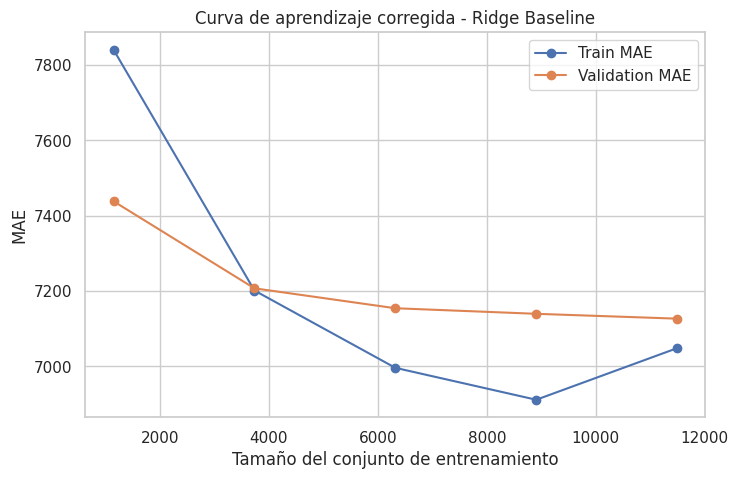

In [ ]:
# ============================================================
# 24. Curva de aprendizaje corregida con clipping integrado
# ============================================================

from sklearn.base import BaseEstimator, RegressorMixin, clone

class ClippedRidgeRegressor(BaseEstimator, RegressorMixin):
    """
    Estimador Ridge con transformación logarítmica del target
    y clipping de predicciones basado en un percentil del target
    observado durante entrenamiento.

    Esto permite usar el mismo comportamiento dentro de validación
    cruzada y curvas de aprendizaje.
    """

    def __init__(self, preprocessor, alpha=1.0, cap_quantile=0.995):
        self.preprocessor = preprocessor
        self.alpha = alpha
        self.cap_quantile = cap_quantile

    def fit(self, X, y):
        self.pred_cap_ = pd.Series(y).quantile(self.cap_quantile)

        ridge_pipeline = Pipeline(steps=[
            ("preprocessor", clone(self.preprocessor)),
            ("model", Ridge(alpha=self.alpha))
        ])

        self.model_ = TransformedTargetRegressor(
            regressor=ridge_pipeline,
            func=np.log1p,
            inverse_func=np.expm1
        )

        self.model_.fit(X, y)
        return self

    def predict(self, X):
        pred = self.model_.predict(X)
        pred = np.clip(pred, 0, self.pred_cap_)
        return pred


ridge_baseline_clipped = ClippedRidgeRegressor(
    preprocessor=preprocessor,
    alpha=best_alpha,
    cap_quantile=0.995
)

cv_lc = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=ridge_baseline_clipped,
    X=X_train_model,
    y=y_train,
    cv=cv_lc,
    scoring="neg_mean_absolute_error",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mae = -train_scores.mean(axis=1)
val_mae = -val_scores.mean(axis=1)

learning_curve_df = pd.DataFrame({
    "train_size": train_sizes,
    "train_MAE": train_mae,
    "validation_MAE": val_mae,
    "gap_validation_train": val_mae - train_mae
})

display(learning_curve_df)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mae, marker="o", label="Train MAE")
plt.plot(train_sizes, val_mae, marker="o", label="Validation MAE")
plt.title("Curva de aprendizaje corregida - Ridge Baseline")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

La curva de aprendizaje corregida permite evaluar la estabilidad del baseline sin distorsiones causadas por predicciones extremas. Si las curvas de entrenamiento y validación se mantienen relativamente cercanas, no hay evidencia fuerte de sobreajuste. Si ambas curvas presentan errores altos, el modelo puede estar limitado por su simplicidad o por la señal disponible en las variables.

### 12.3 Validación cruzada corregida del baseline

Además de la separación train/validation/test, se aplica validación cruzada sobre el conjunto de entrenamiento para evaluar la estabilidad del baseline.

La validación cruzada se realiza con el mismo estimador utilizado conceptualmente en el modelo final: Ridge Regression con transformación logarítmica del target y clipping de predicciones basado en el percentil 99.5 del target observado en cada fold de entrenamiento.

In [ ]:
# ============================================================
# 25. Validación cruzada corregida del baseline
# ============================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

ridge_cv_model = ClippedRidgeRegressor(
    preprocessor=preprocessor,
    alpha=best_alpha,
    cap_quantile=0.995
)

cv_results = cross_validate(
    ridge_cv_model,
    X_train_model,
    y_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "R2": "r2"
    },
    return_train_score=True,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "train_MAE": -cv_results["train_MAE"],
    "validation_MAE": -cv_results["test_MAE"],
    "train_R2": cv_results["train_R2"],
    "validation_R2": cv_results["test_R2"]
})

display(cv_summary)

print("MAE validación cruzada promedio:", cv_summary["validation_MAE"].mean())
print("Desviación estándar MAE:", cv_summary["validation_MAE"].std())
print("R² validación cruzada promedio:", cv_summary["validation_R2"].mean())

,train_MAE,validation_MAE,train_R2,validation_R2
0,"6,965.87","7,449.30",0.09,0.13
1,"7,113.99","6,868.37",0.09,0.11
2,"7,180.58","6,662.69",0.08,0.19
3,"6,868.78","7,861.49",0.17,0.04
4,"7,161.91","6,719.69",0.07,0.24


MAE validación cruzada promedio: 7112.306609022293
Desviación estándar MAE: 522.1695937889277
R² validación cruzada promedio: 0.141589158451702


La validación cruzada corregida permite evaluar si el baseline mantiene un desempeño razonablemente estable en distintas particiones del conjunto de entrenamiento. Si el MAE promedio de validación cruzada es cercano al MAE observado en validación y prueba, se fortalece la evidencia de que el desempeño del baseline es consistente.

## 13. Importancia de características

La importancia de características se analiza mediante dos enfoques complementarios:

1. Coeficientes del modelo Ridge.
2. Permutation importance.

Los coeficientes permiten interpretar la dirección e intensidad relativa de cada variable después del preprocesamiento. Sin embargo, debido a que algunas variables categóricas son codificadas mediante one-hot encoding, su interpretación debe realizarse con cautela.

Por ello, se complementa el análisis con permutation importance, que mide cuánto se deteriora el desempeño del modelo cuando una variable es aleatorizada.

,feature,coeficiente,abs_coeficiente
109,cat__CODIGO_ESTADO_MOR,-0.30,0.30
102,cat__CODIGO_ESTADO_COL,0.28,0.28
118,cat__CODIGO_ESTADO_SLP,-0.23,0.23
100,cat__CODIGO_ESTADO_CHI,0.21,0.21
99,cat__CODIGO_ESTADO_CAM,-0.19,0.19
80,cat__CIUDAD_CHILPANCINGO DE LOS BRAVO,-0.19,0.19
106,cat__CODIGO_ESTADO_GTO,-0.16,0.16
81,cat__CIUDAD_FRONTERA,0.16,0.16
46,num__SUM_MONTO_OTORG,0.13,0.13
96,cat__CIUDAD_SAN PEDRO GARZA GARCIA,0.13,0.13


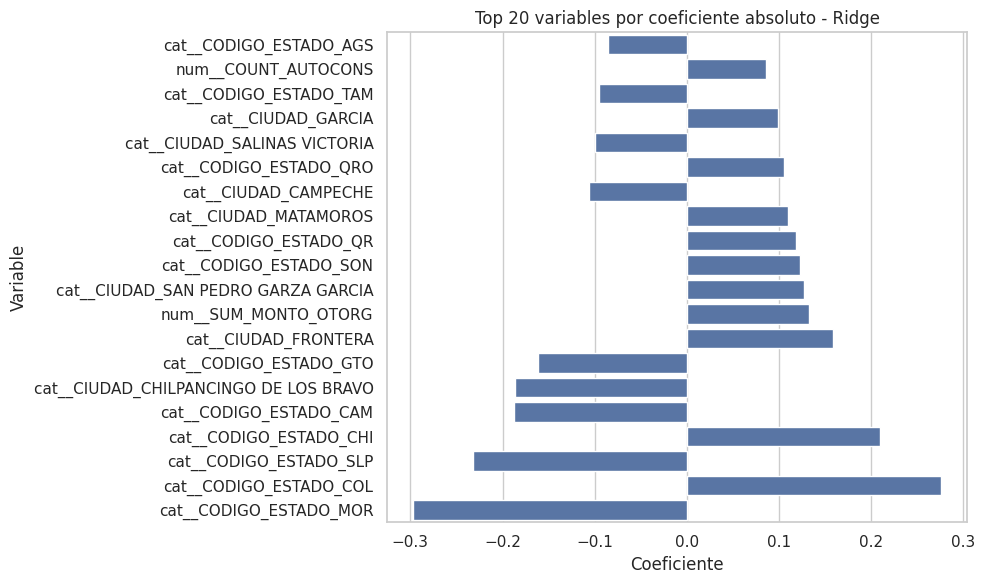

In [ ]:
# ============================================================
# 26. Importancia de características por coeficientes Ridge
# ============================================================

trained_pipeline = ridge_baseline.regressor_
trained_preprocessor = trained_pipeline.named_steps["preprocessor"]
trained_model = trained_pipeline.named_steps["model"]

feature_names = trained_preprocessor.get_feature_names_out()

coeficientes = pd.DataFrame({
    "feature": feature_names,
    "coeficiente": trained_model.coef_
})

coeficientes["abs_coeficiente"] = coeficientes["coeficiente"].abs()

top_coef = (
    coeficientes
    .sort_values("abs_coeficiente", ascending=False)
    .head(20)
)

display(top_coef)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_coef.sort_values("abs_coeficiente", ascending=True),
    x="coeficiente",
    y="feature"
)
plt.title("Top 20 variables por coeficiente absoluto - Ridge")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

Los coeficientes del modelo Ridge permiten observar qué variables tienen mayor peso dentro del modelo lineal regularizado. Las variables con mayor valor absoluto en sus coeficientes son aquellas que más influyen en la predicción.

Sin embargo, cuando una variable categórica se codifica mediante one-hot encoding, cada categoría genera una columna independiente. Por ello, la interpretación debe realizarse de forma relativa frente a la categoría base implícita.

,variable_original,importancia_total,coeficiente_promedio,num_features
0,CODIGO_ESTADO,2.29,0.00,24
1,CIUDAD,1.40,0.00,20
2,ESTADO_CIVIL,0.25,-0.00,7
3,SUM_MONTO_OTORG,0.13,0.13,1
4,SEXO,0.12,-0.00,2
5,COUNT_AUTOCONS,0.09,0.09,1
6,COUNT_FLAG_CLOSED,0.08,0.08,1
7,COUNT_FLAG_SALDO_VDO,0.08,-0.08,1
8,MAX_PEOR_MOP_IN_18M,0.08,0.08,1
9,FLAG_TIENE_SALDO_VENCIDO,0.07,-0.07,1


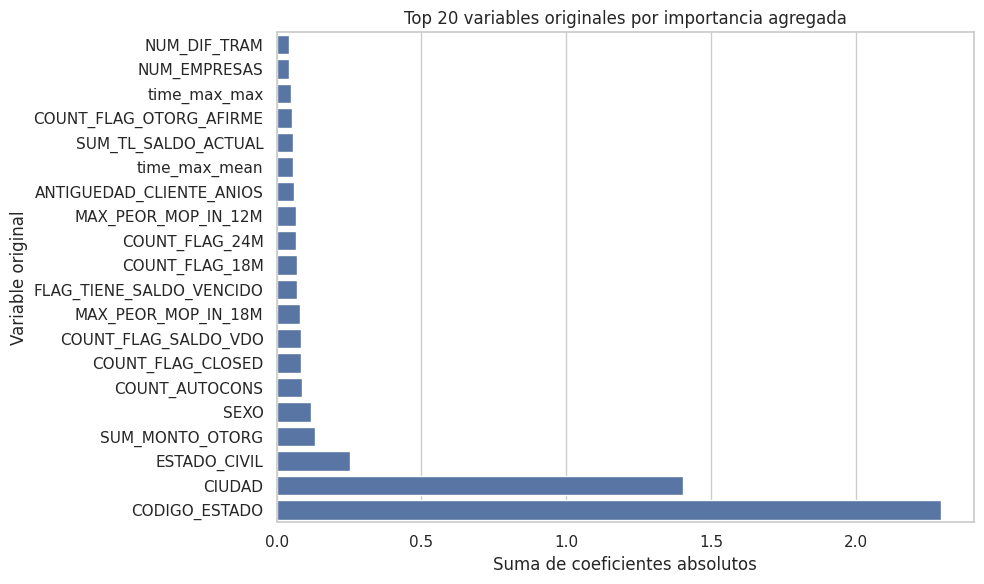

In [ ]:
# ============================================================
# 27. Agrupación de coeficientes por variable original
# ============================================================

def obtener_variable_original(feature_name, categorical_features):
    """
    Convierte nombres transformados del ColumnTransformer a variables originales.
    """
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")

    if feature_name.startswith("cat__"):
        clean_name = feature_name.replace("cat__", "")
        for col in categorical_features:
            if clean_name.startswith(col + "_"):
                return col
        return clean_name

    return feature_name


coeficientes["variable_original"] = coeficientes["feature"].apply(
    lambda x: obtener_variable_original(x, categorical_features)
)

coef_agrupado = (
    coeficientes
    .groupby("variable_original")
    .agg(
        importancia_total=("abs_coeficiente", "sum"),
        coeficiente_promedio=("coeficiente", "mean"),
        num_features=("feature", "count")
    )
    .sort_values("importancia_total", ascending=False)
    .head(20)
    .reset_index()
)

display(coef_agrupado)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_agrupado.sort_values("importancia_total", ascending=True),
    x="importancia_total",
    y="variable_original"
)
plt.title("Top 20 variables originales por importancia agregada")
plt.xlabel("Suma de coeficientes absolutos")
plt.ylabel("Variable original")
plt.tight_layout()
plt.show()

,feature,importance_mean,importance_std
47,MAX_PEOR_MOP_IN_18M,"4,549.44","4,362.43"
41,COUNT_FLAG_24M,"4,363.87","3,263.87"
16,time_max_mean,"3,448.46","2,831.83"
24,COUNT_AUTOCONS,"2,846.42","3,541.66"
49,SUM_TL_SALDO_ACTUAL,"2,458.78",353.10
44,MAX_PEOR_MOP_IN_6M,"1,803.41","1,535.65"
67,RATIO_SALDO_VENCIDO_ACTUAL,"1,401.33","1,495.07"
19,COUNT_9M,"1,317.27","2,079.52"
42,COUNT_FLAG_MAS_24M,"1,268.24","1,268.51"
22,COUNT_24M,892.09,"1,343.93"


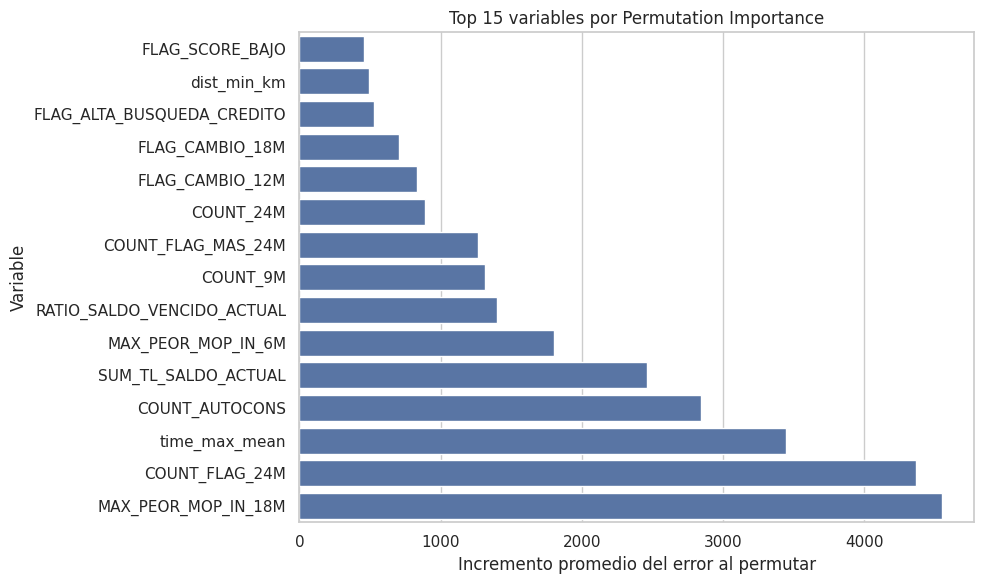

In [ ]:
# ============================================================
# 28. Permutation Importance
# ============================================================

# Para evitar tiempos excesivos, se usa una muestra del conjunto de validación si es muy grande.
MAX_PERMUTATION_ROWS = 5000

if X_val_model.shape[0] > MAX_PERMUTATION_ROWS:
    X_perm = X_val_model.sample(
        n=MAX_PERMUTATION_ROWS,
        random_state=RANDOM_STATE
    )
    y_perm = y_val.loc[X_perm.index]
else:
    X_perm = X_val_model
    y_perm = y_val

perm_result = permutation_importance(
    ridge_baseline,
    X_perm,
    y_perm,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": X_perm.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

perm_importance = perm_importance.sort_values(
    "importance_mean",
    ascending=False
)

display(perm_importance.head(20))

top_perm = perm_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_perm.sort_values("importance_mean", ascending=True),
    x="importance_mean",
    y="feature"
)
plt.title("Top 15 variables por Permutation Importance")
plt.xlabel("Incremento promedio del error al permutar")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Interpretación de importancia de características

El análisis de permutation importance sugiere que variables relacionadas con historial crediticio, comportamiento de pago, saldos, movilidad y antigüedad pueden aportar señal predictiva para estimar el ingreso mensual promedio.

No obstante, algunas variables presentan desviaciones estándar elevadas en su importancia. Esto indica que su contribución puede variar dependiendo de la muestra evaluada. Por ello, estas variables deben interpretarse como señales potenciales y no como conclusiones causales.

La importancia de características en este baseline debe entenderse como un análisis exploratorio de relevancia predictiva, no como una explicación definitiva del comportamiento financiero del cliente.

## 14. Análisis de errores por segmento de ingreso

Además de evaluar el desempeño global, se analiza el error por deciles de ingreso. Este análisis permite identificar si el modelo tiene un comportamiento estable en diferentes segmentos o si falla más en clientes con ingresos bajos, medios o altos.

Este análisis es importante porque una métrica global puede ocultar errores concentrados en ciertos grupos de clientes.

In [ ]:
# ============================================================
# 29. Análisis de error y sesgo por decil de ingreso
# ============================================================

df_errores = pd.DataFrame({
    "y_real": y_test,
    "y_pred": ridge_pred_test
})

df_errores["error"] = df_errores["y_pred"] - df_errores["y_real"]
df_errores["error_abs"] = np.abs(df_errores["error"])
df_errores["error_pct"] = df_errores["error_abs"] / df_errores["y_real"]

df_errores["decil_ingreso"] = pd.qcut(
    df_errores["y_real"],
    q=10,
    duplicates="drop"
)

error_por_decil = (
    df_errores
    .groupby("decil_ingreso", observed=True)
    .agg(
        n=("y_real", "size"),
        ingreso_promedio=("y_real", "mean"),
        ingreso_mediano=("y_real", "median"),
        prediccion_promedio=("y_pred", "mean"),
        sesgo_promedio=("error", "mean"),
        mae=("error_abs", "mean"),
        medae=("error_abs", "median"),
        mape=("error_pct", "mean")
    )
    .reset_index()
)

display(error_por_decil)

,decil_ingreso,n,ingreso_promedio,ingreso_mediano,prediccion_promedio,sesgo_promedio,mae,medae,mape
0,"(745.344, 7025.95]",575,"5,427.01","5,771.33","11,986.52","6,559.51","6,559.51","6,091.50",1.47
1,"(7025.95, 8384.584]",575,"7,782.25","7,802.48","11,983.43","4,201.18","4,220.51","3,888.51",0.55
2,"(8384.584, 9509.512]",574,"8,928.93","8,923.38","12,425.92","3,496.98","3,598.89","3,023.53",0.40
3,"(9509.512, 10767.573]",575,"10,104.24","10,077.40","12,579.23","2,474.99","2,683.06","2,164.77",0.27
4,"(10767.573, 12334.944]",575,"11,530.90","11,504.25","12,912.41","1,381.51","2,217.23","1,616.67",0.19
5,"(12334.944, 14320.109]",574,"13,266.41","13,265.23","13,489.28",222.87,"2,462.50","1,919.09",0.19
6,"(14320.109, 17111.51]",575,"15,588.57","15,503.59","13,860.66","-1,727.91","3,227.61","2,657.83",0.21
7,"(17111.51, 21074.674]",574,"18,961.24","18,864.14","14,593.11","-4,368.13","5,003.89","4,910.03",0.26
8,"(21074.674, 29053.742]",575,"24,507.70","24,314.93","15,967.72","-8,539.98","9,054.13","9,268.61",0.37
9,"(29053.742, 240469.968]",575,"49,699.65","39,006.78","19,873.36","-29,826.30","30,727.03","22,044.86",0.56


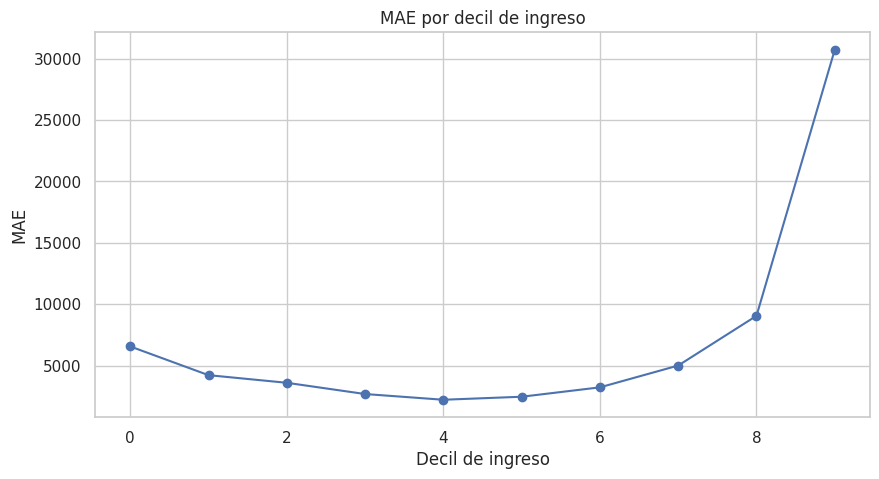

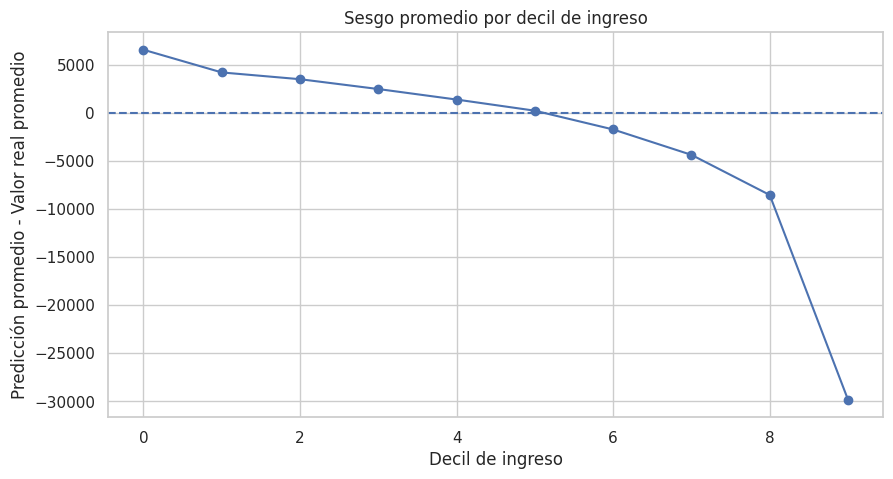

In [ ]:
# ============================================================
# 30. Visualización de MAE por decil
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(
    range(len(error_por_decil)),
    error_por_decil["mae"],
    marker="o"
)
plt.title("MAE por decil de ingreso")
plt.xlabel("Decil de ingreso")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    range(len(error_por_decil)),
    error_por_decil["sesgo_promedio"],
    marker="o"
)
plt.axhline(0, linestyle="--")
plt.title("Sesgo promedio por decil de ingreso")
plt.xlabel("Decil de ingreso")
plt.ylabel("Predicción promedio - Valor real promedio")
plt.grid(True)
plt.show()

### Interpretación del error por segmento

El análisis por deciles muestra que el desempeño del modelo no necesariamente es uniforme en todos los segmentos de ingreso. En general, los segmentos de ingreso alto suelen presentar errores absolutos mayores, debido a que existe mayor dispersión y presencia de valores extremos.

Desde una perspectiva de negocio, esto implica que el baseline puede ser más útil para aproximar ingresos en segmentos medios de la distribución, pero menos preciso para clientes con ingresos atípicamente altos.

Esta limitación es esperada en un modelo lineal simple y refuerza la necesidad de comparar el baseline contra modelos no lineales en etapas posteriores.

## 15. Valores reales vs predichos

El gráfico de valores reales vs predichos permite observar visualmente la capacidad del modelo para aproximarse a los ingresos observados.

La línea diagonal representa predicción perfecta. Se utiliza escala logarítmica para facilitar la lectura visual debido a la fuerte asimetría de la variable objetivo.

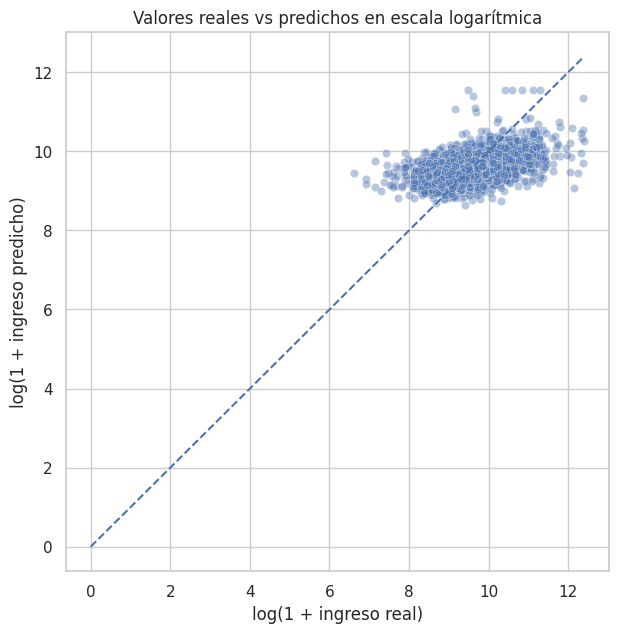

In [ ]:
# ============================================================
# 31. Valores reales vs predichos
# ============================================================

plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=np.log1p(y_test),
    y=np.log1p(ridge_pred_test),
    alpha=0.4
)

max_val = max(
    np.log1p(y_test).max(),
    np.log1p(ridge_pred_test).max()
)

plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.title("Valores reales vs predichos en escala logarítmica")
plt.xlabel("log(1 + ingreso real)")
plt.ylabel("log(1 + ingreso predicho)")
plt.grid(True)
plt.show()

## 16. Análisis de residuos

El análisis de residuos permite evaluar si los errores del modelo presentan patrones sistemáticos. Idealmente, los residuos deberían distribuirse alrededor de cero sin patrones evidentes.

Si se observan patrones claros, podría indicar que el modelo lineal no está capturando relaciones no lineales o que existen segmentos de clientes donde el desempeño es menos estable.

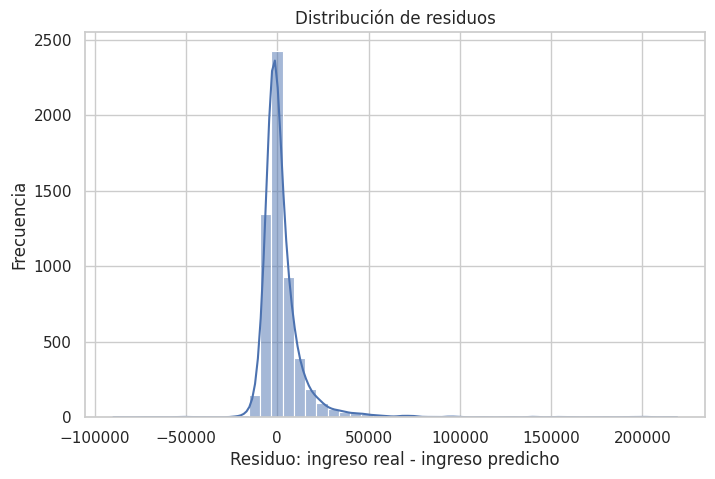

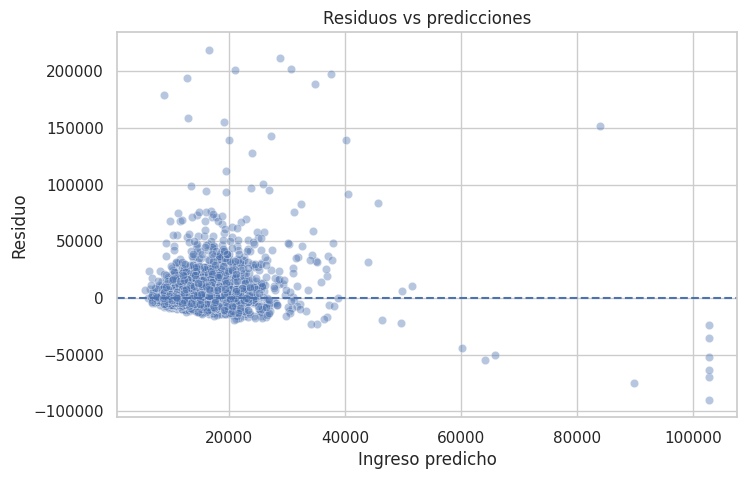

In [ ]:
# ============================================================
# 32. Análisis de residuos
# ============================================================

residuos = y_test - ridge_pred_test

plt.figure(figsize=(8, 5))
sns.histplot(residuos, bins=50, kde=True)
plt.title("Distribución de residuos")
plt.xlabel("Residuo: ingreso real - ingreso predicho")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=ridge_pred_test,
    y=residuos,
    alpha=0.4
)
plt.axhline(0, linestyle="--")
plt.title("Residuos vs predicciones")
plt.xlabel("Ingreso predicho")
plt.ylabel("Residuo")
plt.grid(True)
plt.show()

## 17. Tabla ejecutiva final de métricas

Se presenta una tabla final comparando el modelo ingenuo contra el modelo baseline en el conjunto de prueba. Esta tabla resume el desempeño final del avance y permite evaluar si el baseline supera el desempeño mínimo esperado.

In [ ]:
# ============================================================
# 33. Tabla ejecutiva final
# ============================================================

tabla_final = pd.DataFrame([
    evaluar_regresion("Dummy Median - Test", y_test, dummy_pred_test),
    evaluar_regresion(f"Ridge alpha={best_alpha} - Test", y_test, ridge_pred_test)
])

display(tabla_final)
display(formatear_metricas(tabla_final))

print(f"Mejora en MAE vs Dummy: {mejora_mae:.2%}")
print(f"Mejora en RMSE vs Dummy: {mejora_rmse:.2%}")

,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Dummy Median - Test,"7,827.20","16,342.11","4,137.53",0.46,0.47,-0.07
1,Ridge alpha=10.0 - Test,"6,977.15","14,562.64","3,937.28",0.45,0.42,0.15


,modelo,MAE,RMSE,MedAE,MAPE,WAPE,R2
0,Dummy Median - Test,"$7,827.20","$16,342.11","$4,137.53",46.26%,47.21%,-0.0724
1,Ridge alpha=10.0 - Test,"$6,977.15","$14,562.64","$3,937.28",44.65%,42.08%,0.1485


Mejora en MAE vs Dummy: 10.86%
Mejora en RMSE vs Dummy: 10.89%


### Interpretación del desempeño

El modelo Ridge supera al modelo ingenuo en el conjunto de prueba, reduciendo el MAE en aproximadamente 10.86%. Esto indica que las variables disponibles sí contienen señal predictiva por encima de una predicción trivial.

Sin embargo, el R² del modelo se mantiene relativamente bajo. Esto significa que, aunque el baseline mejora el error promedio, todavía explica una proporción limitada de la variabilidad total del ingreso mensual. Esta situación es razonable para un baseline lineal en un problema con alta dispersión, outliers y posibles relaciones no lineales.

Por lo tanto, el resultado debe interpretarse como una solución mínima de referencia, no como un modelo final de producción.

## 18. Cumplimiento de la rúbrica

| Criterio | Evidencia en el notebook |
|---|---|
| Algoritmo | Se seleccionó Ridge Regression con transformación logarítmica del target y se justificó su uso por simplicidad, interpretabilidad y regularización L2. |
| Características importantes | Se analizaron coeficientes del modelo, coeficientes agrupados por variable original y permutation importance. |
| Sub/sobreajuste | Se compararon métricas en entrenamiento, validación y prueba, y se complementó con curva de aprendizaje y validación cruzada. |
| Métrica | Se eligió MAE como métrica principal por su interpretación directa en pesos mexicanos. También se reportaron RMSE, MedAE, MAPE, WAPE y R². |
| Desempeño | Se comparó el baseline contra un Dummy Regressor y se definió como mínimo aceptable una mejora de 10% en MAE. |

In [ ]:
# ============================================================
# 34. Generación automática de conclusión con resultados reales
# ============================================================

ridge_r2_test = tabla_final.loc[
    tabla_final["modelo"] == f"Ridge alpha={best_alpha} - Test",
    "R2"
].values[0]

ridge_wape_test = tabla_final.loc[
    tabla_final["modelo"] == f"Ridge alpha={best_alpha} - Test",
    "WAPE"
].values[0]

conclusion_markdown = f"""
# Conclusiones del Avance 3 - Baseline

En este avance se construyó un modelo baseline para estimar `AVG_ING_MENSUAL`, correspondiente al ingreso mensual promedio de clientes de nómina. El problema se abordó como una tarea de regresión supervisada, ya que la variable objetivo es numérica y continua.

Como modelo ingenuo de referencia se utilizó `DummyRegressor`, el cual predice siempre la mediana del ingreso mensual observada en el conjunto de entrenamiento. Este modelo obtuvo un MAE de aproximadamente **${dummy_mae:,.2f}** en el conjunto de prueba.

El modelo baseline seleccionado fue **Ridge Regression con transformación logarítmica del target**. Este algoritmo fue elegido por su simplicidad, interpretabilidad y regularización L2, lo que lo convierte en una opción adecuada para establecer un punto de comparación inicial en datos tabulares.

El modelo Ridge obtuvo un MAE de aproximadamente **${ridge_mae:,.2f}** en prueba, lo que representa una mejora de **{mejora_mae:.2%}** frente al modelo ingenuo. Bajo el criterio definido de reducir al menos **10%** el MAE frente al Dummy Regressor, el baseline **{"sí supera" if mejora_mae >= MIN_MEJORA_MAE else "no supera"}** el desempeño mínimo esperado.

La métrica principal seleccionada fue **MAE**, debido a que permite interpretar el error promedio directamente en pesos mexicanos. También se reportaron RMSE, MedAE, MAPE, WAPE y R² como métricas complementarias. En el conjunto de prueba, el modelo Ridge obtuvo un R² de **{ridge_r2_test:.4f}** y un WAPE de **{ridge_wape_test:.2%}**.

El análisis de importancia de variables permitió identificar las características con mayor contribución al desempeño del modelo. La interpretación se realizó mediante coeficientes del modelo Ridge, coeficientes agrupados por variable original y permutation importance.

El análisis de errores por decil permitió revisar si el desempeño era homogéneo entre segmentos de ingreso. Este análisis es relevante porque una métrica global puede ocultar errores concentrados en clientes con ingresos altos o bajos.

Finalmente, el baseline construido proporciona un marco de referencia simple, interpretable y reproducible. Sus resultados permiten evaluar si modelos más avanzados, como Random Forest, Gradient Boosting, XGBoost o LightGBM, logran mejoras significativas frente a una solución lineal regularizada.
"""

display(Markdown(conclusion_markdown))


# Conclusiones del Avance 3 - Baseline

En este avance se construyó un modelo baseline para estimar `AVG_ING_MENSUAL`, correspondiente al ingreso mensual promedio de clientes de nómina. El problema se abordó como una tarea de regresión supervisada, ya que la variable objetivo es numérica y continua.

Como modelo ingenuo de referencia se utilizó `DummyRegressor`, el cual predice siempre la mediana del ingreso mensual observada en el conjunto de entrenamiento. Este modelo obtuvo un MAE de aproximadamente **$7,827.20** en el conjunto de prueba.

El modelo baseline seleccionado fue **Ridge Regression con transformación logarítmica del target**. Este algoritmo fue elegido por su simplicidad, interpretabilidad y regularización L2, lo que lo convierte en una opción adecuada para establecer un punto de comparación inicial en datos tabulares.

El modelo Ridge obtuvo un MAE de aproximadamente **$6,977.15** en prueba, lo que representa una mejora de **10.86%** frente al modelo ingenuo. Bajo el criterio definido de reducir al menos **10%** el MAE frente al Dummy Regressor, el baseline **sí supera** el desempeño mínimo esperado.

La métrica principal seleccionada fue **MAE**, debido a que permite interpretar el error promedio directamente en pesos mexicanos. También se reportaron RMSE, MedAE, MAPE, WAPE y R² como métricas complementarias. En el conjunto de prueba, el modelo Ridge obtuvo un R² de **0.1485** y un WAPE de **42.08%**.

El análisis de importancia de variables permitió identificar las características con mayor contribución al desempeño del modelo. La interpretación se realizó mediante coeficientes del modelo Ridge, coeficientes agrupados por variable original y permutation importance.

El análisis de errores por decil permitió revisar si el desempeño era homogéneo entre segmentos de ingreso. Este análisis es relevante porque una métrica global puede ocultar errores concentrados en clientes con ingresos altos o bajos.

Finalmente, el baseline construido proporciona un marco de referencia simple, interpretable y reproducible. Sus resultados permiten evaluar si modelos más avanzados, como Random Forest, Gradient Boosting, XGBoost o LightGBM, logran mejoras significativas frente a una solución lineal regularizada.


In [ ]:
# ============================================================
# Decisión final del baseline
# ============================================================

decision_baseline = pd.DataFrame({
    "Criterio": [
        "Variable objetivo",
        "Tipo de problema",
        "Métrica principal",
        "Modelo ingenuo",
        "Modelo baseline",
        "MAE Dummy Test",
        "MAE Ridge Test",
        "Mejora MAE vs Dummy",
        "Desempeño mínimo esperado",
        "¿Supera mínimo?",
        "R² Test",
        "WAPE Test",
        "Decisión final"
    ],
    "Resultado": [
        TARGET,
        "Regresión supervisada",
        "MAE",
        "DummyRegressor(strategy='median')",
        f"Ridge Regression alpha={best_alpha}",
        f"${dummy_mae:,.2f}",
        f"${ridge_mae:,.2f}",
        f"{mejora_mae:.2%}",
        "10% de mejora en MAE",
        "Sí" if mejora_mae >= MIN_MEJORA_MAE else "No",
        f"{ridge_r2_test:.4f}",
        f"{ridge_wape_test:.2%}",
        "Baseline aceptable como referencia inicial" if mejora_mae >= MIN_MEJORA_MAE else "Baseline insuficiente"
    ]
})

display(decision_baseline)

,Criterio,Resultado
0,Variable objetivo,AVG_ING_MENSUAL
1,Tipo de problema,Regresión supervisada
2,Métrica principal,MAE
3,Modelo ingenuo,DummyRegressor(strategy='median')
4,Modelo baseline,Ridge Regression alpha=10.0
5,MAE Dummy Test,"$7,827.20"
6,MAE Ridge Test,"$6,977.15"
7,Mejora MAE vs Dummy,10.86%
8,Desempeño mínimo esperado,10% de mejora en MAE
9,¿Supera mínimo?,Sí


# Conclusiones del Avance 3 - Baseline

En este avance se construyó un modelo baseline para estimar `AVG_ING_MENSUAL`, correspondiente al ingreso mensual promedio de clientes de nómina. El problema se abordó como una tarea de regresión supervisada, ya que la variable objetivo es numérica y continua.

Como modelo ingenuo de referencia se utilizó `DummyRegressor`, el cual predice siempre la mediana del ingreso mensual observada en el conjunto de entrenamiento. Este modelo obtuvo un MAE de aproximadamente **$7,827.20** en el conjunto de prueba.

El modelo baseline seleccionado fue **Ridge Regression con transformación logarítmica del target**. Este algoritmo fue elegido por su simplicidad, interpretabilidad y regularización L2, lo que lo convierte en una opción adecuada para establecer un punto de comparación inicial en datos tabulares.

El modelo Ridge con `alpha = 10` obtuvo un MAE de aproximadamente **$6,977.15** en prueba, lo que representa una mejora de **10.86%** frente al modelo ingenuo. Bajo el criterio definido de reducir al menos **10%** el MAE frente al Dummy Regressor, el baseline **sí supera** el desempeño mínimo esperado.

La métrica principal seleccionada fue **MAE**, debido a que permite interpretar el error promedio directamente en pesos mexicanos. También se reportaron RMSE, MedAE, MAPE, WAPE y R² como métricas complementarias. En el conjunto de prueba, el modelo Ridge obtuvo un R² de **0.1485** y un WAPE de **42.08%**.

Aunque el baseline supera el desempeño mínimo esperado, el margen de mejora es reducido. Esto indica que las variables disponibles sí contienen señal predictiva, pero también que el modelo lineal tiene una capacidad explicativa limitada para capturar toda la variabilidad del ingreso mensual.

El análisis de importancia de variables permitió identificar características relacionadas con historial crediticio, comportamiento de pago, saldos, movilidad, antigüedad y ubicación geográfica como posibles fuentes de señal predictiva. Estos resultados deben interpretarse como relevancia predictiva y no como relaciones causales.

El análisis de errores por decil mostró que el desempeño no es uniforme entre segmentos de ingreso. Los clientes con ingresos altos concentran mayores errores absolutos, mientras que en los segmentos bajos el modelo tiende a sobreestimar el ingreso. Esta limitación es consistente con la alta asimetría de la variable objetivo y con el uso de un modelo lineal simple.

Finalmente, el baseline construido proporciona un marco de referencia simple, interpretable y reproducible. Sus resultados permiten evaluar si modelos más avanzados, como Random Forest, Gradient Boosting, XGBoost o LightGBM, logran mejoras significativas frente a una solución lineal regularizada.

## 19. Siguientes pasos

A partir del baseline construido, se recomiendan los siguientes pasos:

1. Evaluar modelos no lineales como Random Forest, Gradient Boosting, XGBoost o LightGBM.
2. Revisar el tratamiento de outliers en `AVG_ING_MENSUAL`.
3. Analizar predicciones extremas y validar la estabilidad del modelo.
4. Explorar selección de características para reducir ruido y complejidad.
5. Comparar desempeño por segmentos de clientes.
6. Evaluar técnicas adicionales de calibración o winsorización de predicciones para evitar estimaciones poco realistas.
7. Evaluar modelos segmentados o estrategias específicas para clientes de ingresos altos, dado que este grupo concentra errores absolutos mayores.